# GLFTMM Result Curves

Use `sim/report.py` to discover result folders and plot the curve for every folder.

In [1]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path("/home/kang/glftmm_lot")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

report_tools = importlib.import_module("sim.report")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

Edit the variables below when you want a different symbol, date range, folder keyword, or plotting density.

In [2]:
with open(REPO_ROOT / "config/config.json", "r", encoding="utf-8") as fh:
    CONFIG = json.load(fh)

ROOT_DIR = Path(CONFIG["paths"]["output_dir"])
SYMBOL = CONFIG.get("symbols", ["BTCUSDT"])[0]

# Use None for the full available range. Date format can be YYYY-MM-DD or YYYYMMDD.
SRT = None
END = None
EXCLUDE_DATE = None

# Optional folder-path substring filter, for example "md1" or "pg10x50".
KEYWORD = None

# Larger EVERY is faster and lighter. Set lower for smoother intraday curves.
EVERY = 600

# PNL_ONLY=True plots only total PnL curves. False plots price/inventory/PnL/volume panels.
PNL_ONLY = False
NORMALIZE = False

# Plot folders in batches so each chart remains readable.
BATCH_SIZE = 6
NUM_WORKERS = 4

# Set to an integer while testing, for example 5. Use None for every discovered folder.
MAX_FOLDERS = None

ROOT_DIR, SYMBOL

(PosixPath('/data/users/kang/backtest/glftmm_lot/result'), 'BTCUSDT')

Discover every leaf folder that contains matching parquet reports.

In [3]:
folders, counts = report_tools.get_folders_with_counts(
    ROOT_DIR,
    SYMBOL,
    srt=SRT,
    end=END,
    exclude_date=EXCLUDE_DATE,
    keyword=KEYWORD,
)

folder_df = pd.DataFrame(
    {
        "run_id": np.arange(len(folders), dtype=int),
        "file_count": counts,
        "folder": folders,
    }
)

def run_name(folder: str | Path) -> str:
    path = Path(folder)
    if path.name == "strat__all" and path.parent.name:
        return path.parent.name
    return path.name

if not folder_df.empty:
    folder_df.insert(1, "run_name", folder_df["folder"].map(run_name))

print(f"found {len(folder_df)} folders under {ROOT_DIR}")
display(folder_df)

if folder_df.empty:
    raise FileNotFoundError(
        f"no report parquet folders found under {ROOT_DIR} for symbol={SYMBOL}, keyword={KEYWORD}"
    )

found 80 folders under /data/users/kang/backtest/glftmm_lot/result


,run_id,run_name,file_count,folder
0,0,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,190,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
1,1,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
2,2,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,205,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
3,3,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,59,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
4,4,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
5,5,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,68,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
6,6,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,194,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
7,7,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
8,8,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
9,9,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,60,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...


Helper functions for selecting folders and calling `report_tools.report(...)`.

In [4]:
def choose_folders(
    indices: list[int] | tuple[int, ...] | None = None,
    contains: str | None = None,
    limit: int | None = MAX_FOLDERS,
) -> pd.DataFrame:
    df = folder_df.copy()
    if contains is not None:
        df = df[df["folder"].str.contains(contains, regex=False)]
    if indices is not None:
        wanted = list(indices)
        df = df[df["run_id"].isin(wanted)]
        df = df.set_index("run_id").reindex(wanted).dropna(subset=["folder"]).reset_index()
    if limit is not None:
        df = df.head(int(limit))
    return df.reset_index(drop=True)


def plot_folder_batch(
    df: pd.DataFrame,
    *,
    pnl_only: bool = PNL_ONLY,
    every: int = EVERY,
    normalize: bool = NORMALIZE,
) -> pd.DataFrame:
    if df.empty:
        raise ValueError("empty folder selection")

    folders_to_plot = df["folder"].tolist()
    labels = [f"{int(run_id):03d}" for run_id in df["run_id"]]

    stats = report_tools.report(
        folders_to_plot,
        every=every,
        pnl_only=pnl_only,
        srt=SRT,
        end=END,
        exclude_date=EXCLUDE_DATE,
        labels=labels,
        normalize=normalize,
        num_workers=NUM_WORKERS,
    )

    metrics = pd.DataFrame(stats)
    metrics.insert(0, "run_id", labels[: len(metrics)])
    metrics.insert(1, "file_count", df["file_count"].to_list()[: len(metrics)])
    metrics.insert(2, "folder", folders_to_plot[: len(metrics)])
    display(metrics)
    return metrics

Plot every discovered folder, split into batches.

batch 1: run_id 000..005


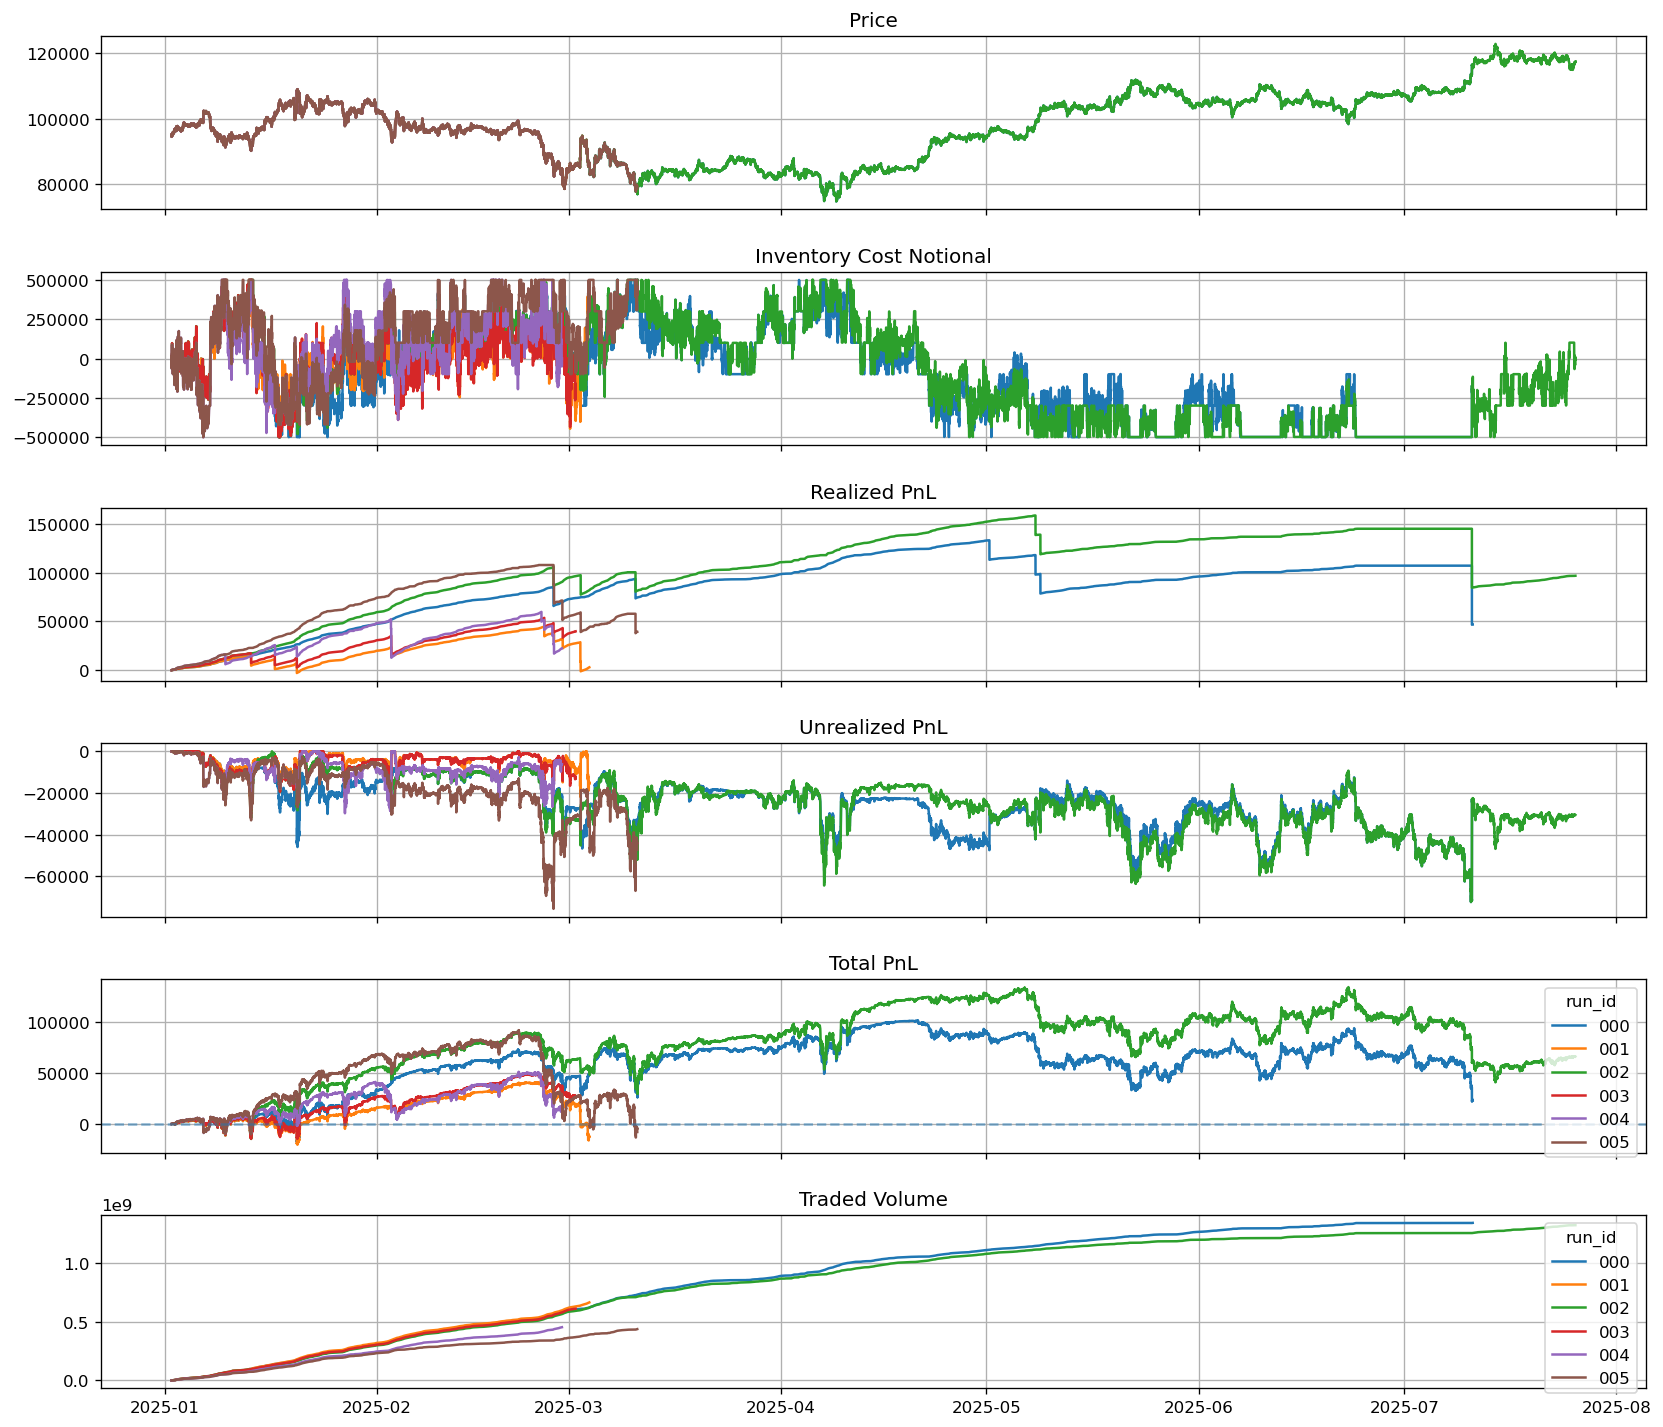

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,000,190,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,23372.735282,0.016448,0.545371,78296.396879,42700.584360,0.545371,0.016448,7.051335e+06,0.000017
1,001,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-12594.076283,-0.049704,-1.584717,53190.106527,-84291.262954,-1.584717,-0.049704,1.091455e+07,-0.000019
2,002,205,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,66365.517112,0.043406,1.439616,80521.250349,115919.670519,1.439616,0.043406,6.437659e+06,0.000050
3,003,59,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,26948.818928,0.095670,7.326356,21793.113347,159664.102564,7.326356,0.095670,1.037322e+07,0.000044
4,004,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,16182.929819,0.039685,2.307460,38866.218003,89682.258896,2.307460,0.039685,7.944748e+06,0.000036
5,005,68,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-7936.824556,-0.021064,-0.578271,97601.995646,-56440.355953,-0.578271,-0.021064,6.399146e+06,-0.000018


batch 2: run_id 006..011


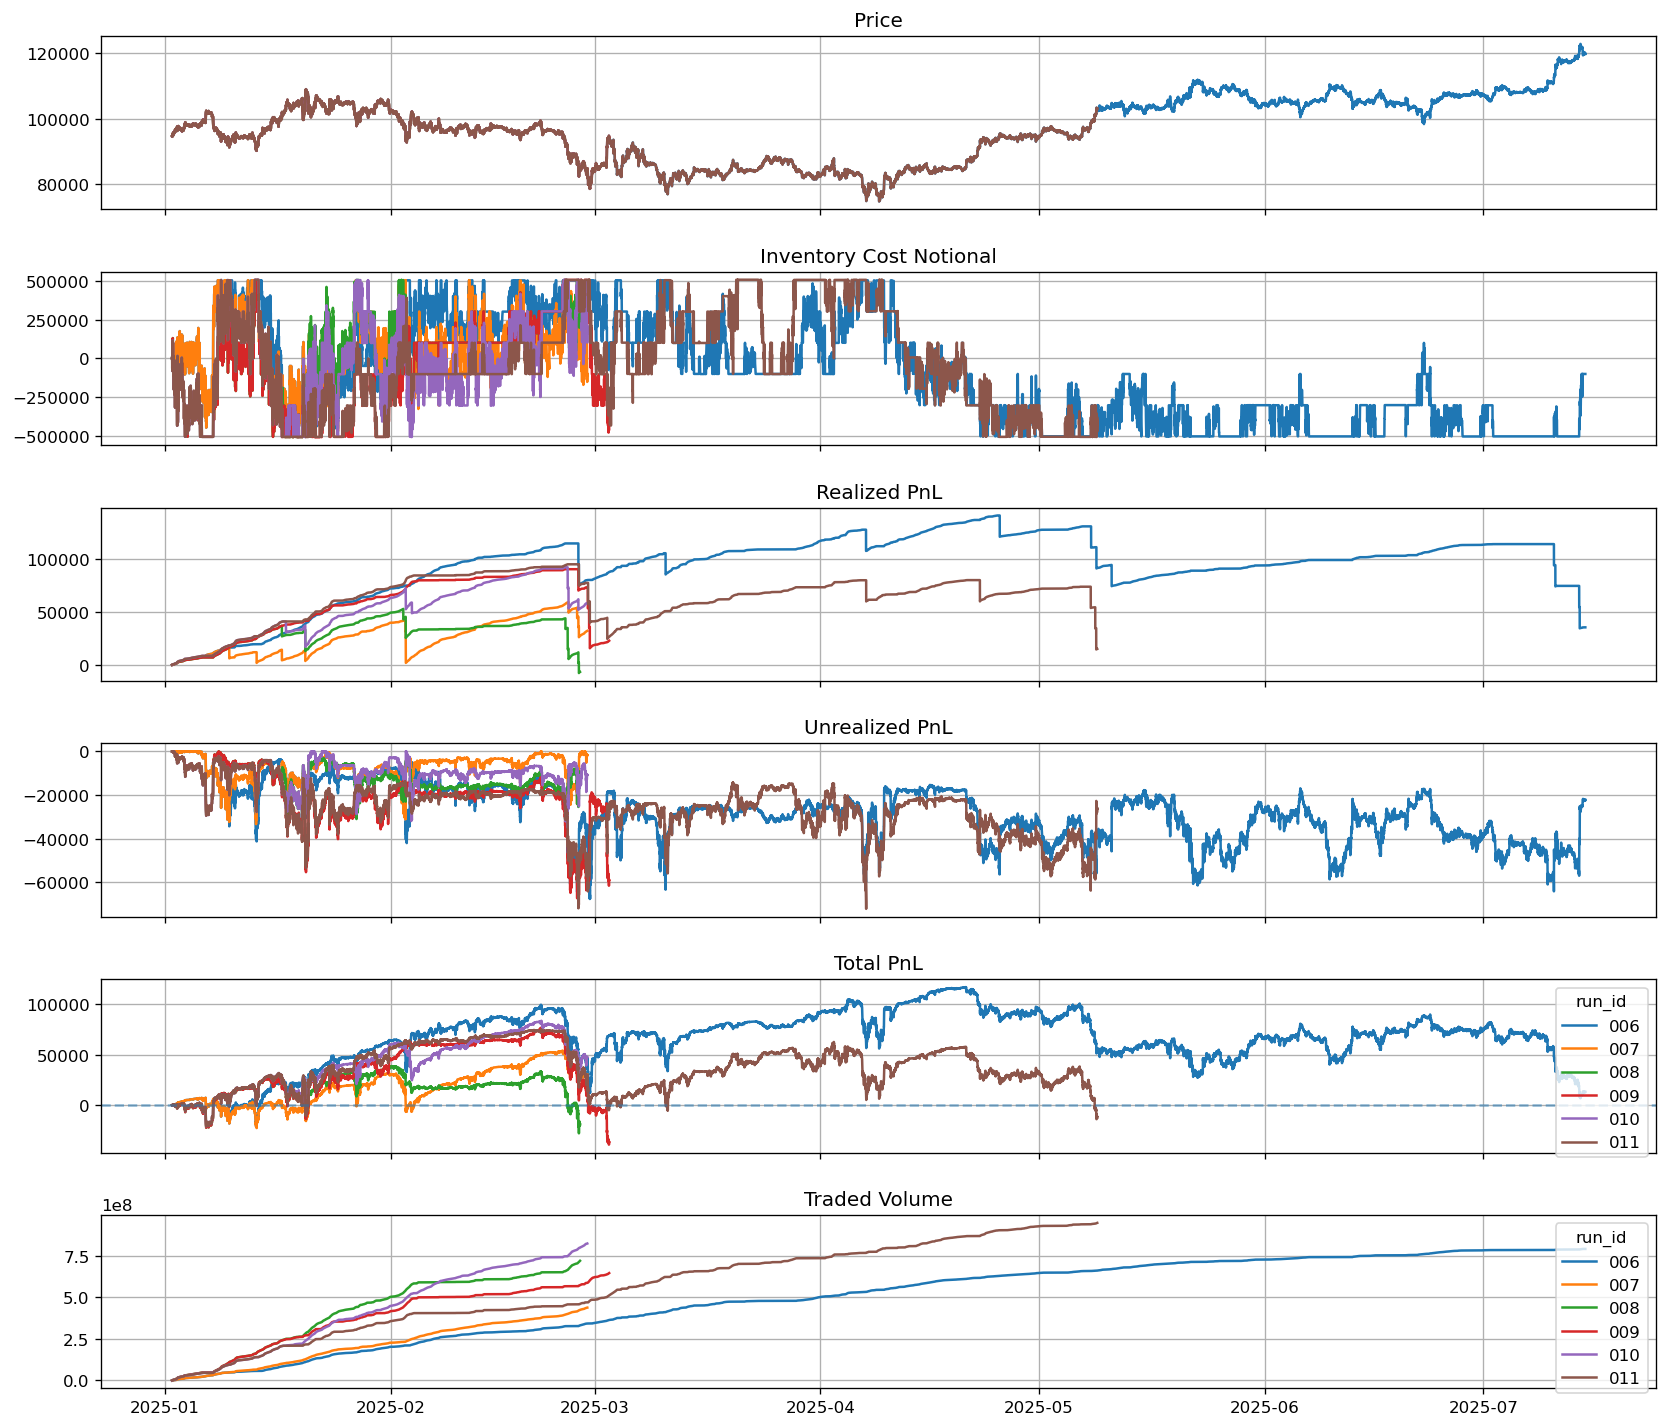

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,006,194,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,13068.244127,0.006848,0.190880,103264.245830,19711.063104,0.190880,0.006848,4.060993e+06,0.000016
1,007,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,30214.505126,0.083791,5.370374,33459.428693,179689.650785,5.370374,0.083791,7.681547e+06,0.000069
2,008,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-18899.803222,-0.043855,-2.184710,56758.028246,-123999.853654,-2.184710,-0.043855,1.274077e+07,-0.000026
3,009,60,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-36206.186561,-0.066165,-2.030078,109679.511584,-222657.997794,-2.030078,-0.066165,1.062392e+07,-0.000056
4,010,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,47403.081775,0.096083,6.973369,43897.580909,306114.042168,6.973369,0.096083,1.438565e+07,0.000057
5,011,127,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-12507.617669,-0.011637,-0.435335,86140.937297,-37500.150284,-0.435335,-0.011637,7.380899e+06,-0.000013


batch 3: run_id 012..017


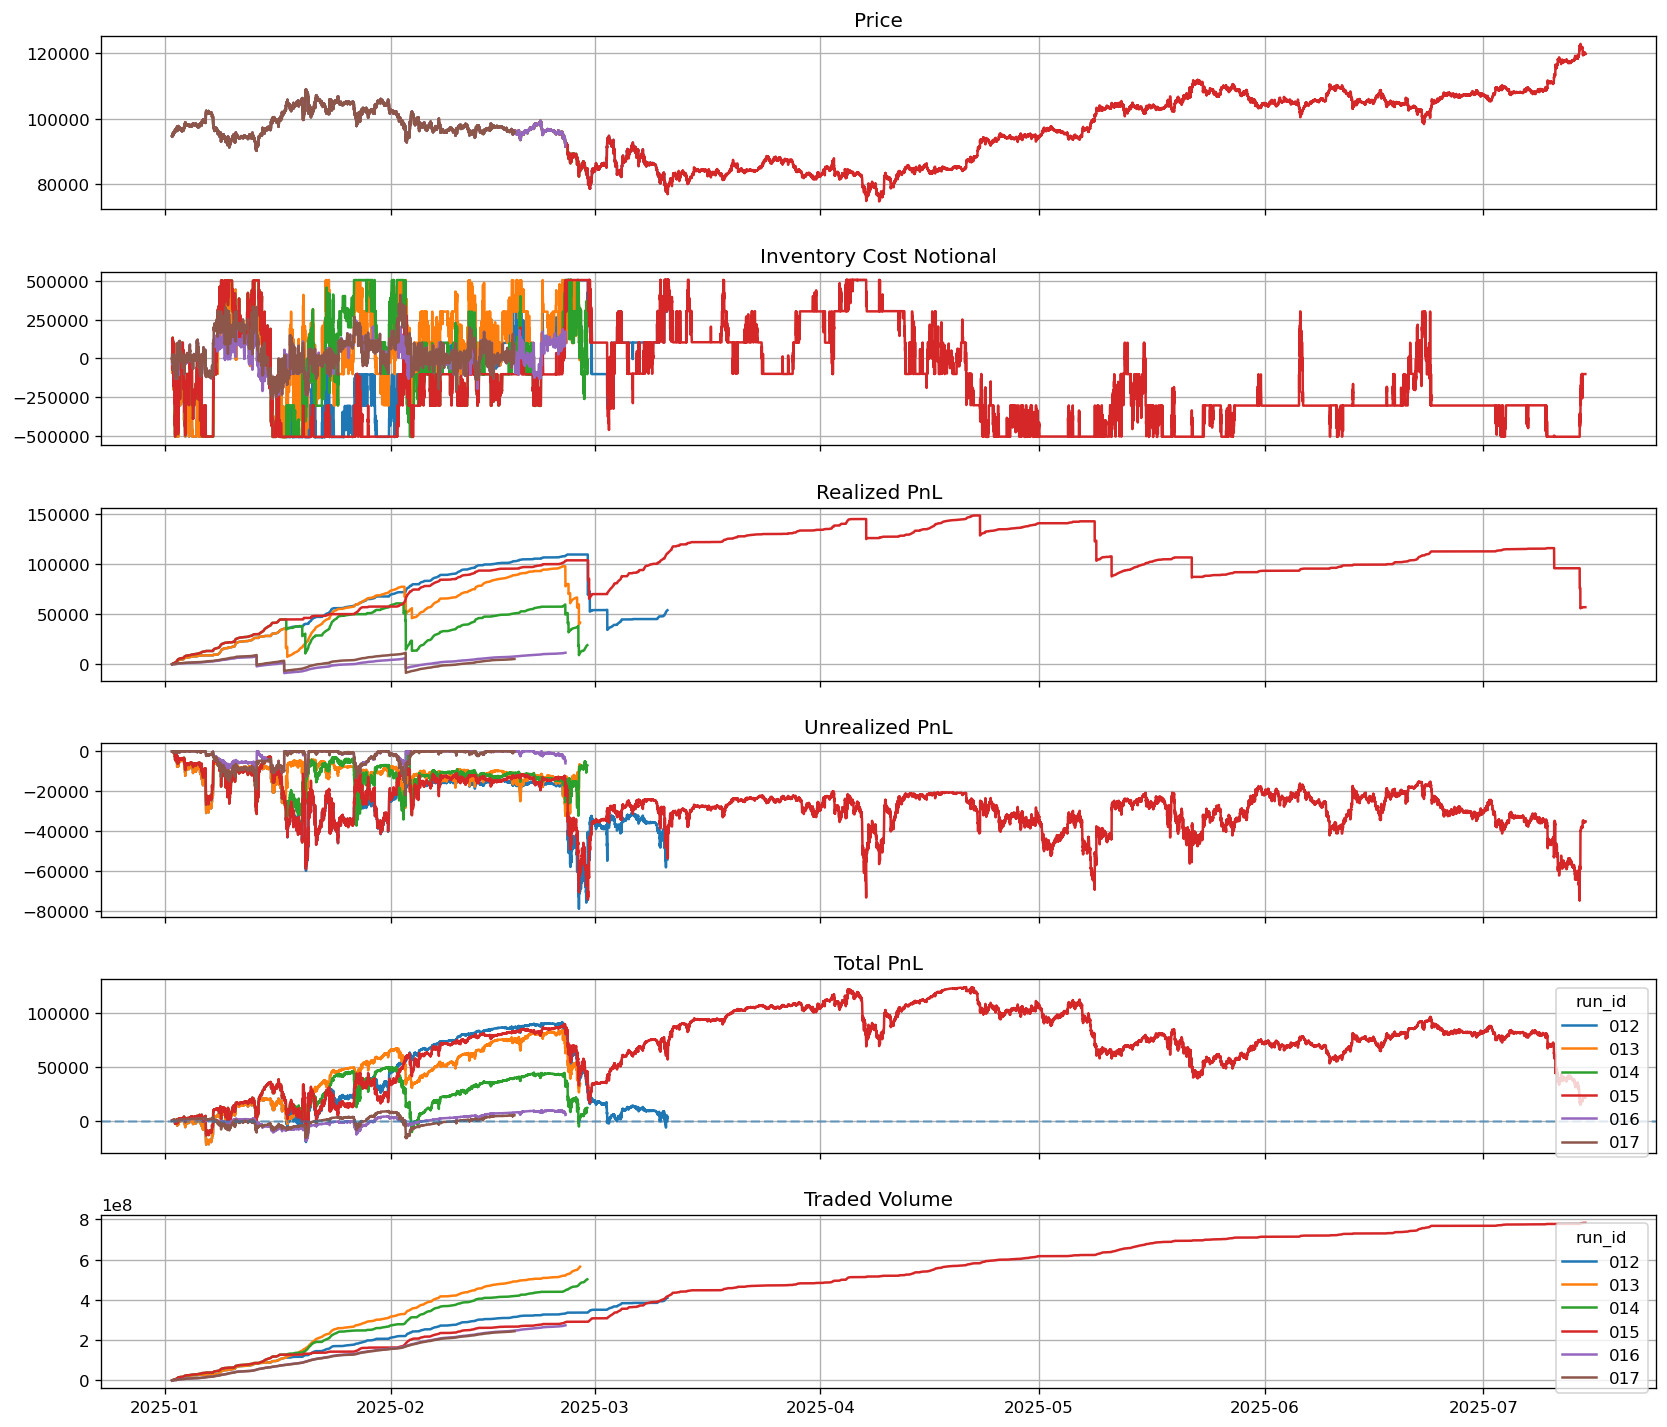

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,012,68,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-353.194144,-0.000222,-0.007551,90815.893547,-685.720517,-0.007551,-0.000222,5.919829e+06,-8.590429e-07
1,013,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,34301.163620,0.075867,4.771512,48023.260982,229143.587439,4.771512,0.075867,1.001223e+07,6.068932e-05
2,014,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,11929.540157,0.018860,1.174370,55346.785195,64997.584620,1.174370,0.018860,8.678709e+06,2.374744e-05
3,015,194,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,21694.373231,0.012618,0.365194,102210.191752,37326.574147,0.365194,0.012618,3.970517e+06,2.771904e-05
4,016,54,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,5478.851915,0.047133,2.719132,12291.556904,33422.362193,2.719132,0.047133,5.066514e+06,2.000832e-05
5,017,47,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,5215.753661,0.037682,2.203644,15924.492009,35091.907699,2.203644,0.037682,5.201681e+06,2.132867e-05


batch 4: run_id 018..023


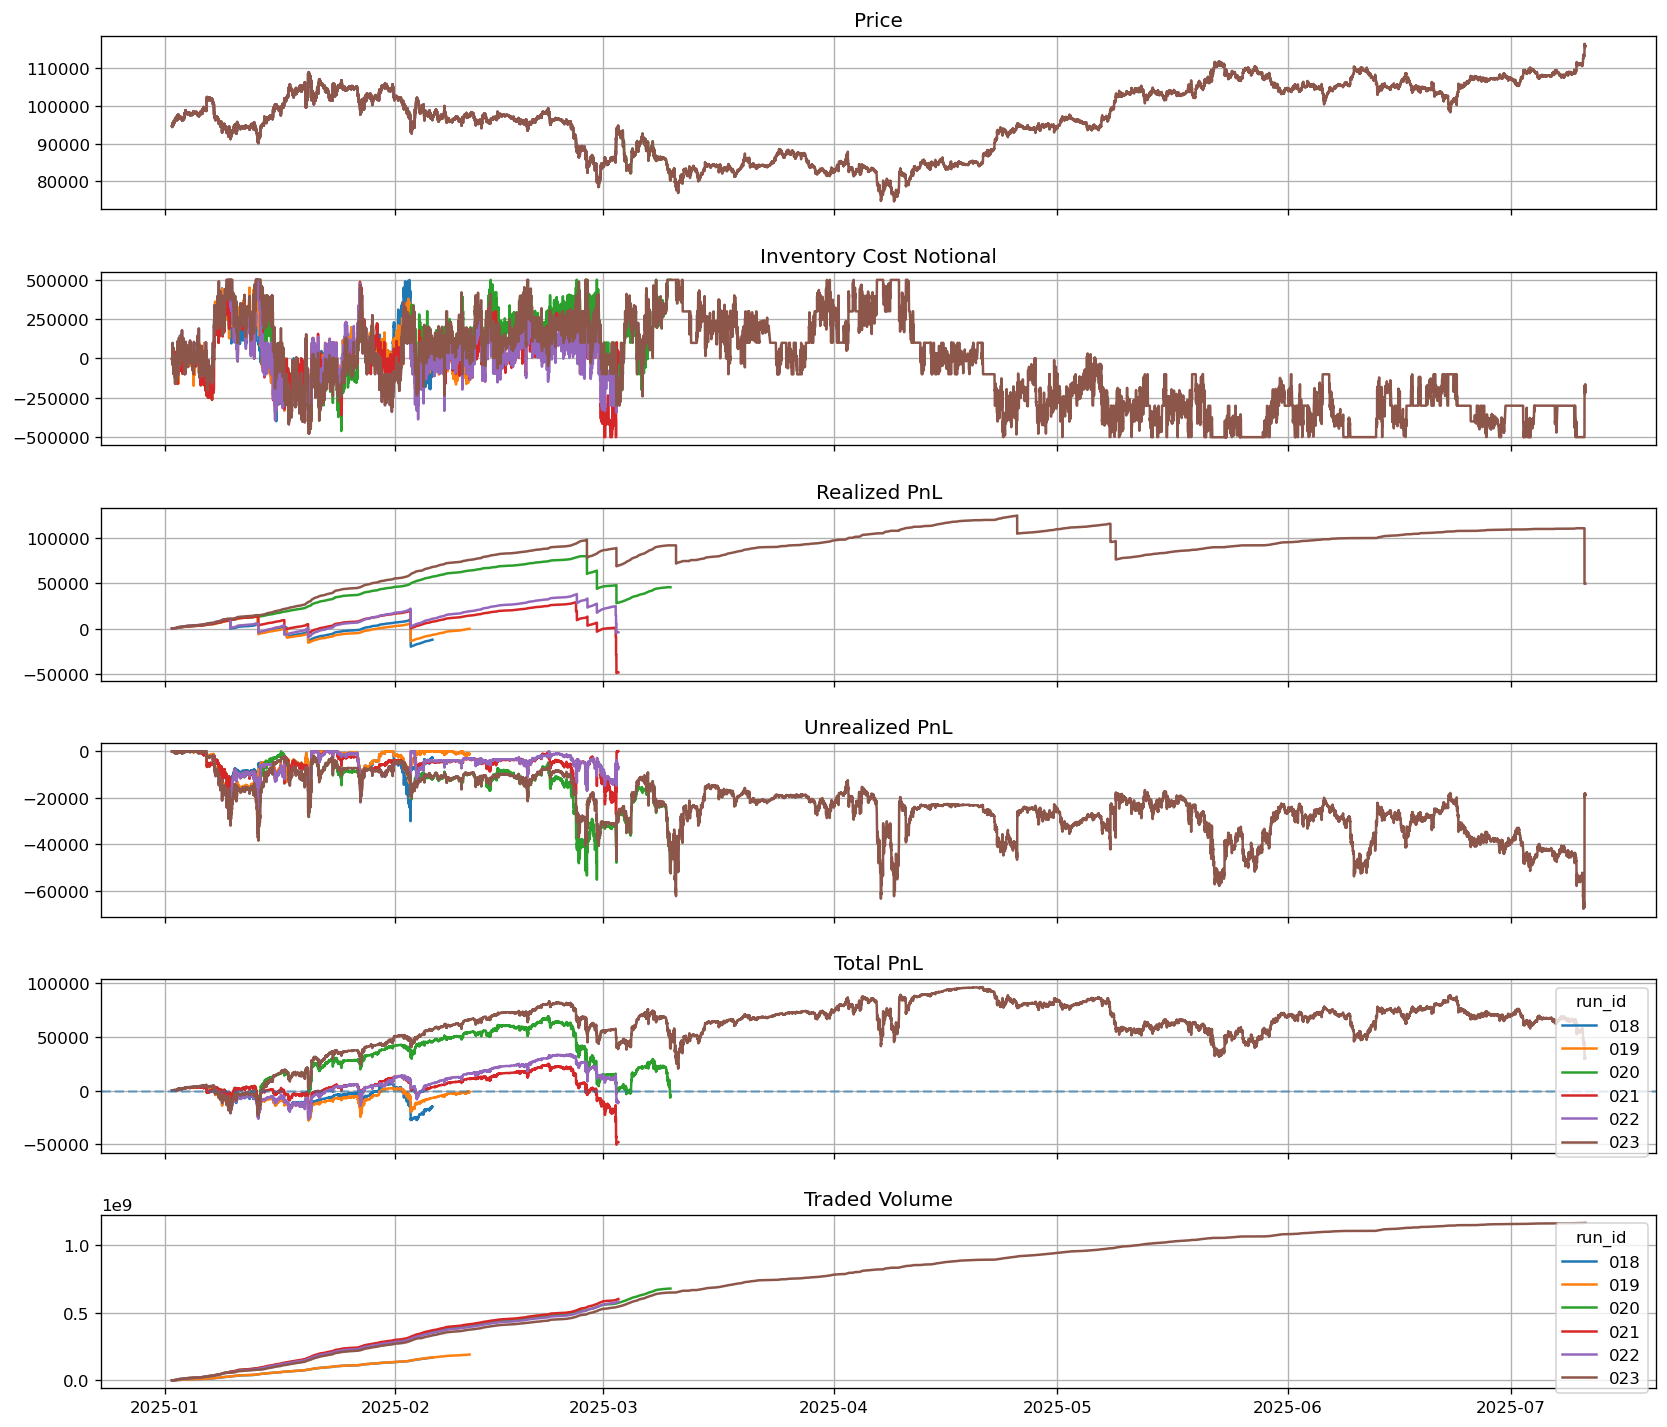

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,018,35,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-14892.499589,-0.101704,-5.626063,31008.439972,-174455.450917,-5.626063,-0.101704,4.833792e+06,-0.000088
1,019,40,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-1423.843044,-0.018158,-1.381362,17904.023352,-24731.938716,-1.381362,-0.018158,4.790931e+06,-0.000007
2,020,67,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-4561.084342,-0.015074,-0.469705,71049.092427,-33372.135815,-0.469705,-0.015074,1.013158e+07,-0.000007
3,021,60,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-48007.371737,-0.150505,-4.293919,71289.053421,-306109.421404,-4.293919,-0.150505,1.003252e+07,-0.000080
4,022,60,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-10549.031846,-0.039305,-1.707339,43721.841595,-74647.992731,-1.707339,-0.039305,9.719051e+06,-0.000018
5,023,190,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,30684.086687,0.021499,0.860461,65461.728536,56327.284093,0.860461,0.021499,6.107518e+06,0.000026


batch 5: run_id 024..029


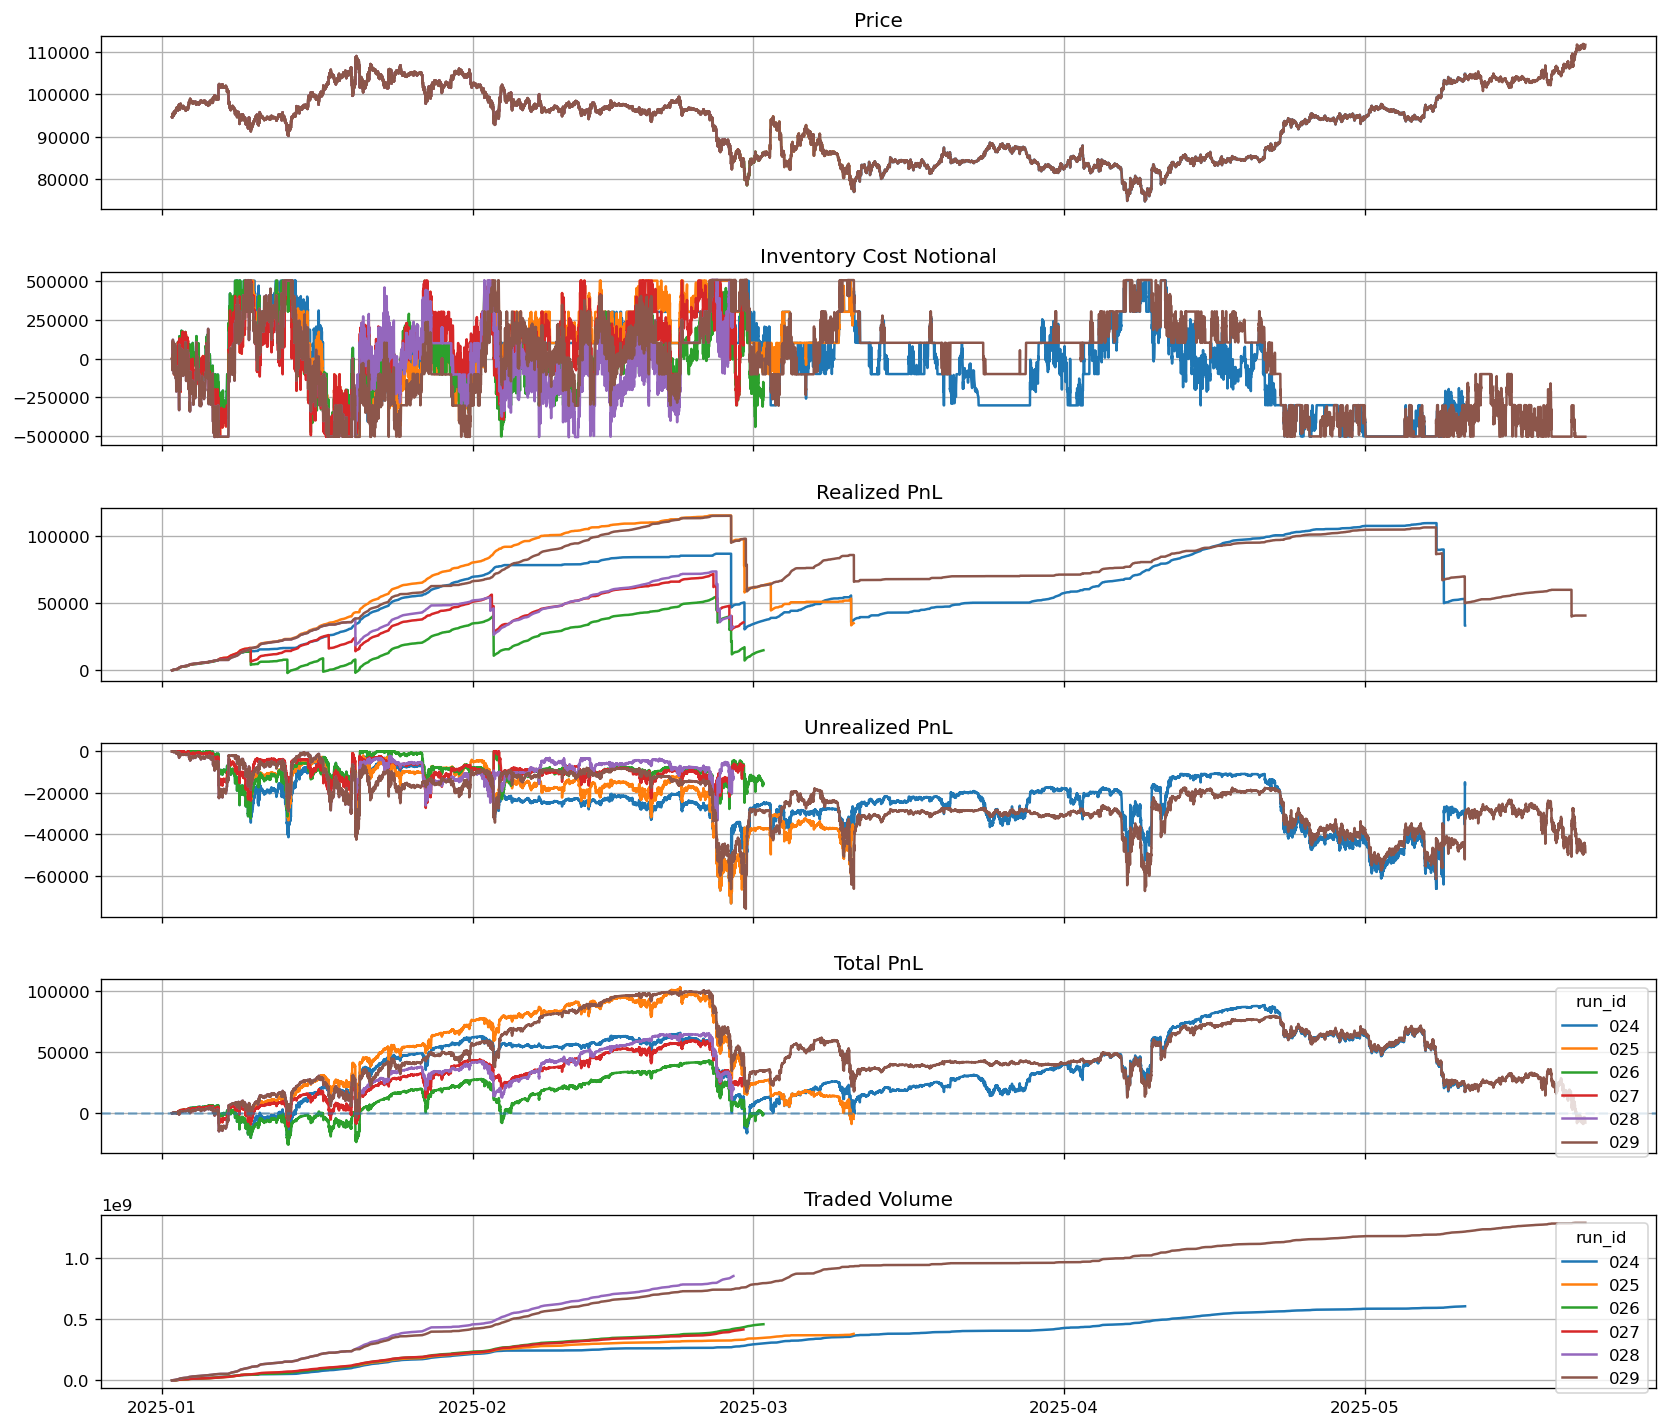

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,024,129,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,17547.459328,0.016120,0.610767,70721.608412,43194.414881,0.610767,0.016120,4.653437e+06,0.000029
1,025,68,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-4592.424316,-0.015157,-0.368476,104939.360258,-38667.674160,-0.368476,-0.015157,5.538087e+06,-0.000012
2,026,59,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-844.316507,-0.008941,-0.474460,43029.473648,-20415.742678,-0.474460,-0.008941,7.748237e+06,-0.000002
3,027,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,28932.868917,0.077905,4.826267,35690.100634,172249.961808,4.826267,0.077905,7.271778e+06,0.000070
4,028,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,20174.797174,0.046519,2.790058,44918.329015,125324.729699,2.790058,0.046519,1.512280e+07,0.000024
5,029,141,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-7690.009948,-0.007876,-0.217617,107587.058919,-23412.817616,-0.217617,-0.007876,9.032503e+06,-0.000006


batch 6: run_id 030..035


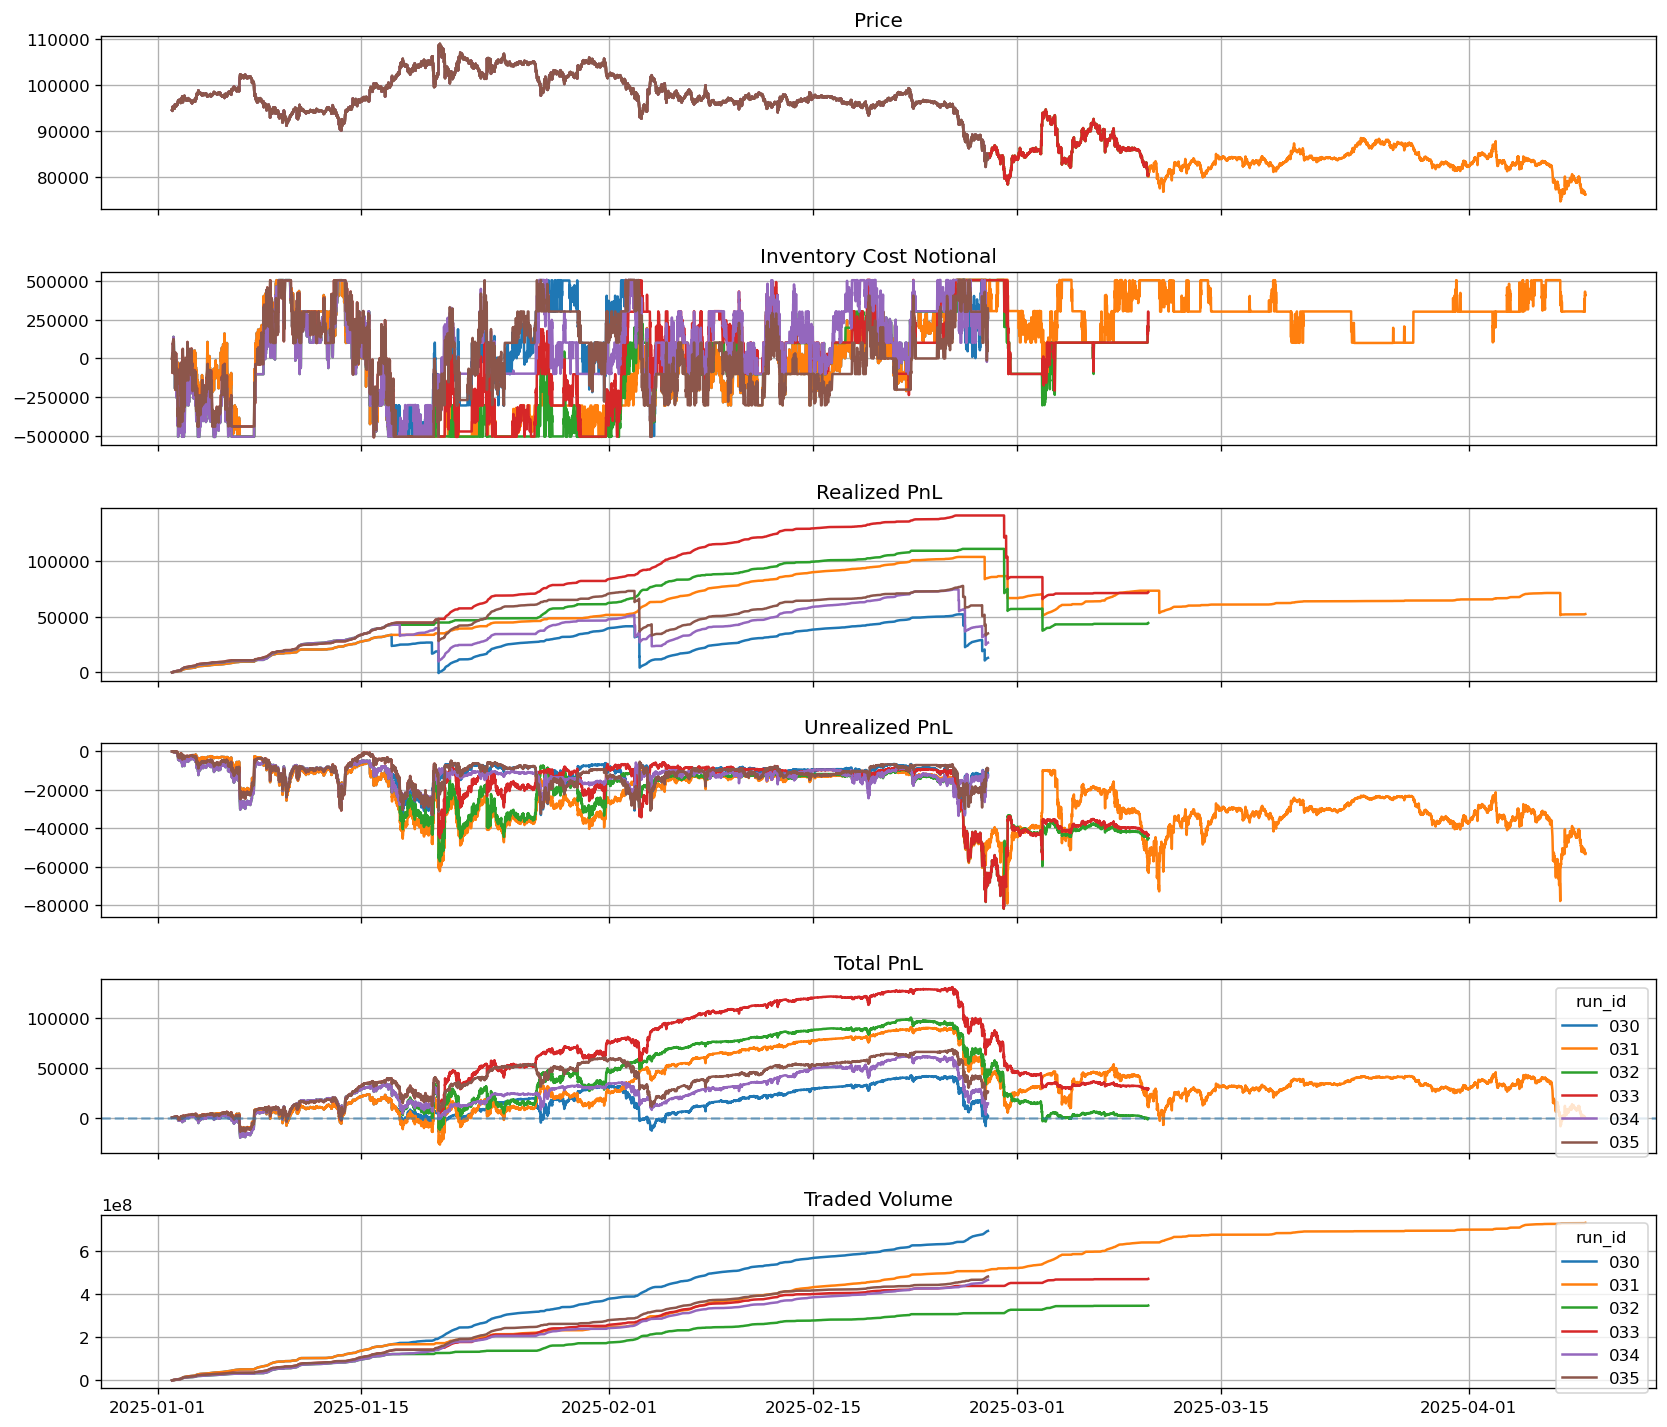

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,030,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,1065.549187,0.001184,0.084286,40263.445145,3393.653344,0.084286,0.001184,1.222521e+07,0.000002
1,031,97,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-731.369971,-0.001467,-0.054104,90339.248423,-4887.755820,-0.054104,-0.001467,7.390904e+06,-0.000001
2,032,67,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-580.804806,-0.000851,-0.028493,99772.953278,-2842.869848,-0.028493,-0.000851,5.034939e+06,-0.000002
3,033,67,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,28892.445803,0.046784,1.463760,100009.664135,146390.184018,1.463760,0.046784,6.871038e+06,0.000062
4,034,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,14071.079009,0.031274,2.012742,46614.912007,93823.785138,2.012742,0.031274,8.198723e+06,0.000030
5,035,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,25924.784084,0.050333,3.567772,43717.410425,155973.738505,3.567772,0.050333,8.441242e+06,0.000054


batch 7: run_id 036..041


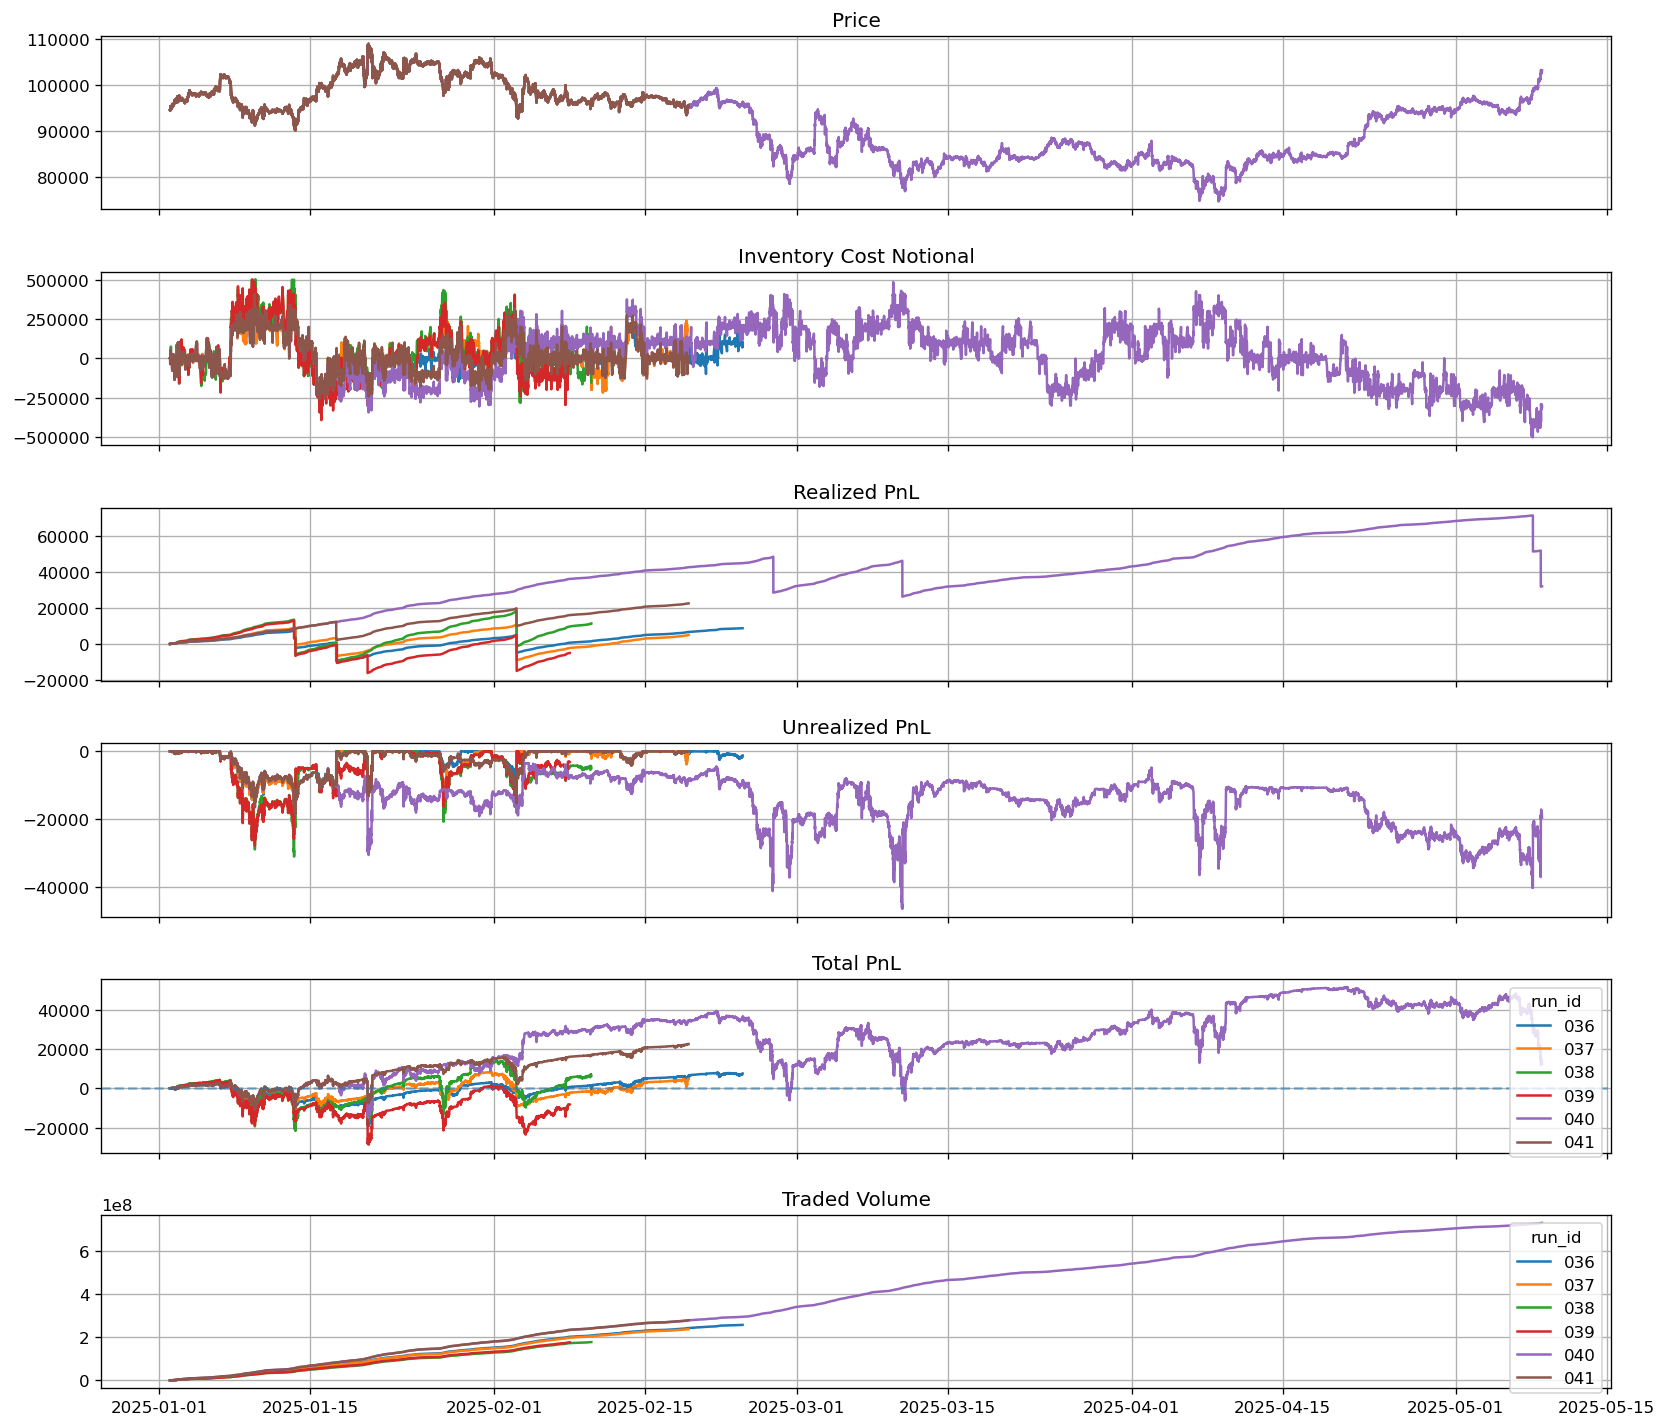

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,036,53,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,7552.168887,0.070513,4.001583,12171.053566,48703.480347,4.001583,0.070513,4.847477e+06,0.000029
1,037,48,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,4790.676186,0.034105,1.957348,16061.938858,31438.801025,1.957348,0.034105,4.954290e+06,0.000020
2,038,39,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,6455.851675,0.029748,2.215060,21369.736514,47335.249232,2.215060,0.029748,4.556998e+06,0.000036
3,039,37,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-8176.233403,-0.055698,-3.835378,24615.845405,-94411.062566,-3.835378,-0.055698,4.776296e+06,-0.000046
4,040,127,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,12504.490053,0.018307,0.864751,39044.964807,33764.157480,0.864751,0.018307,5.741498e+06,0.000017
5,041,48,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,22564.468010,0.245827,19.843497,8498.604982,168642.038236,19.843497,0.245827,5.801743e+06,0.000081


batch 8: run_id 042..047


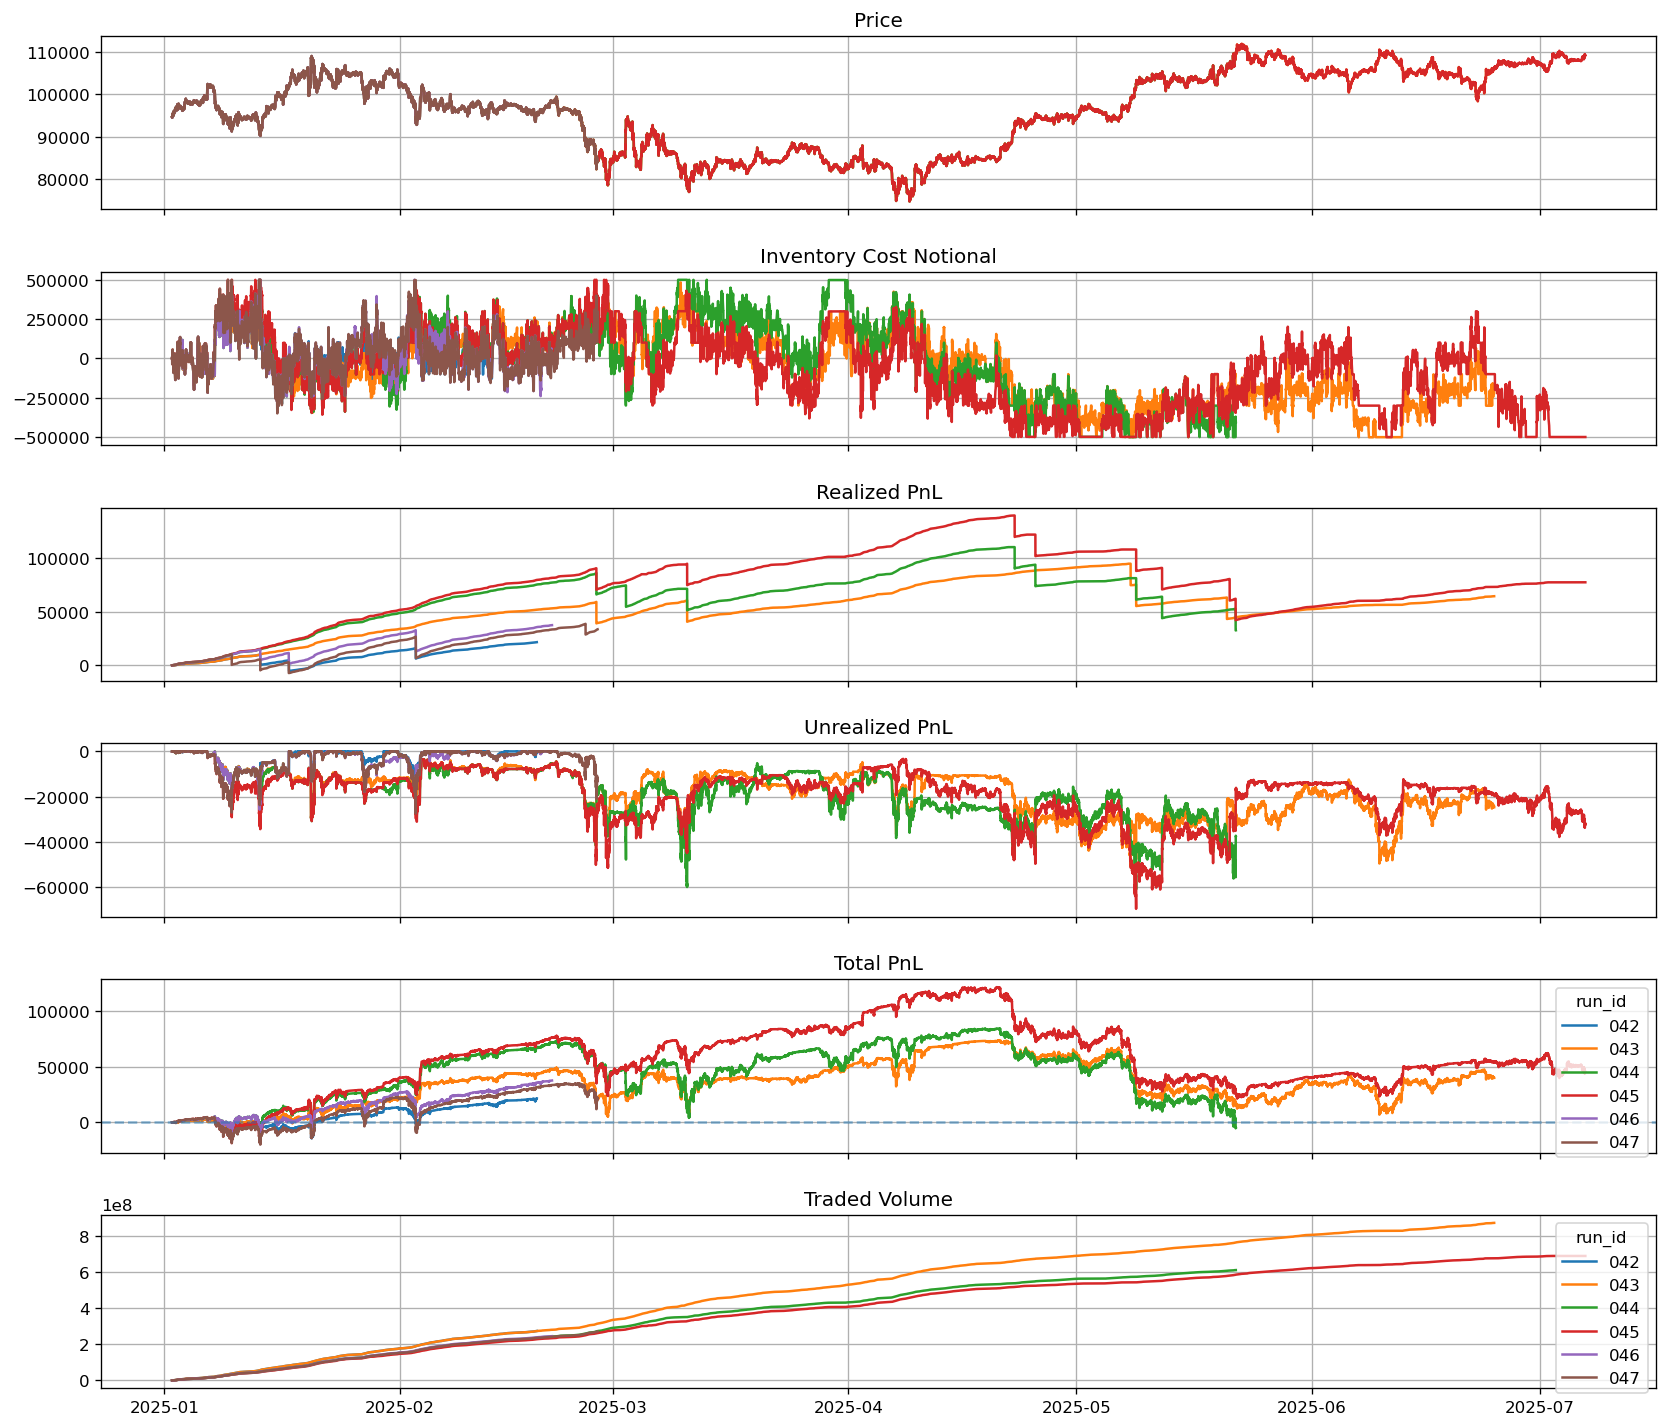

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,042,48,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,21381.425565,0.199013,16.358315,9763.866107,159720.402209,16.358315,0.199013,5.720642e+06,0.000078
1,043,174,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,39888.464516,0.041850,1.267420,65044.625749,82438.890872,1.267420,0.041850,5.022950e+06,0.000046
2,044,140,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-4628.365436,-0.006152,-0.177500,88327.870495,-15678.213921,-0.177500,-0.006152,4.372597e+06,-0.000008
3,045,186,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,45253.011080,0.041039,0.891608,96868.103697,86368.423042,0.891608,0.041039,3.709284e+06,0.000065
4,046,50,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,37523.147726,0.274232,22.842873,11798.464755,269510.827944,22.842873,0.274232,4.919822e+06,0.000153
5,047,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,21212.651053,0.113569,7.864459,16653.579863,130971.397331,7.864459,0.113569,4.860979e+06,0.000078


batch 9: run_id 048..053


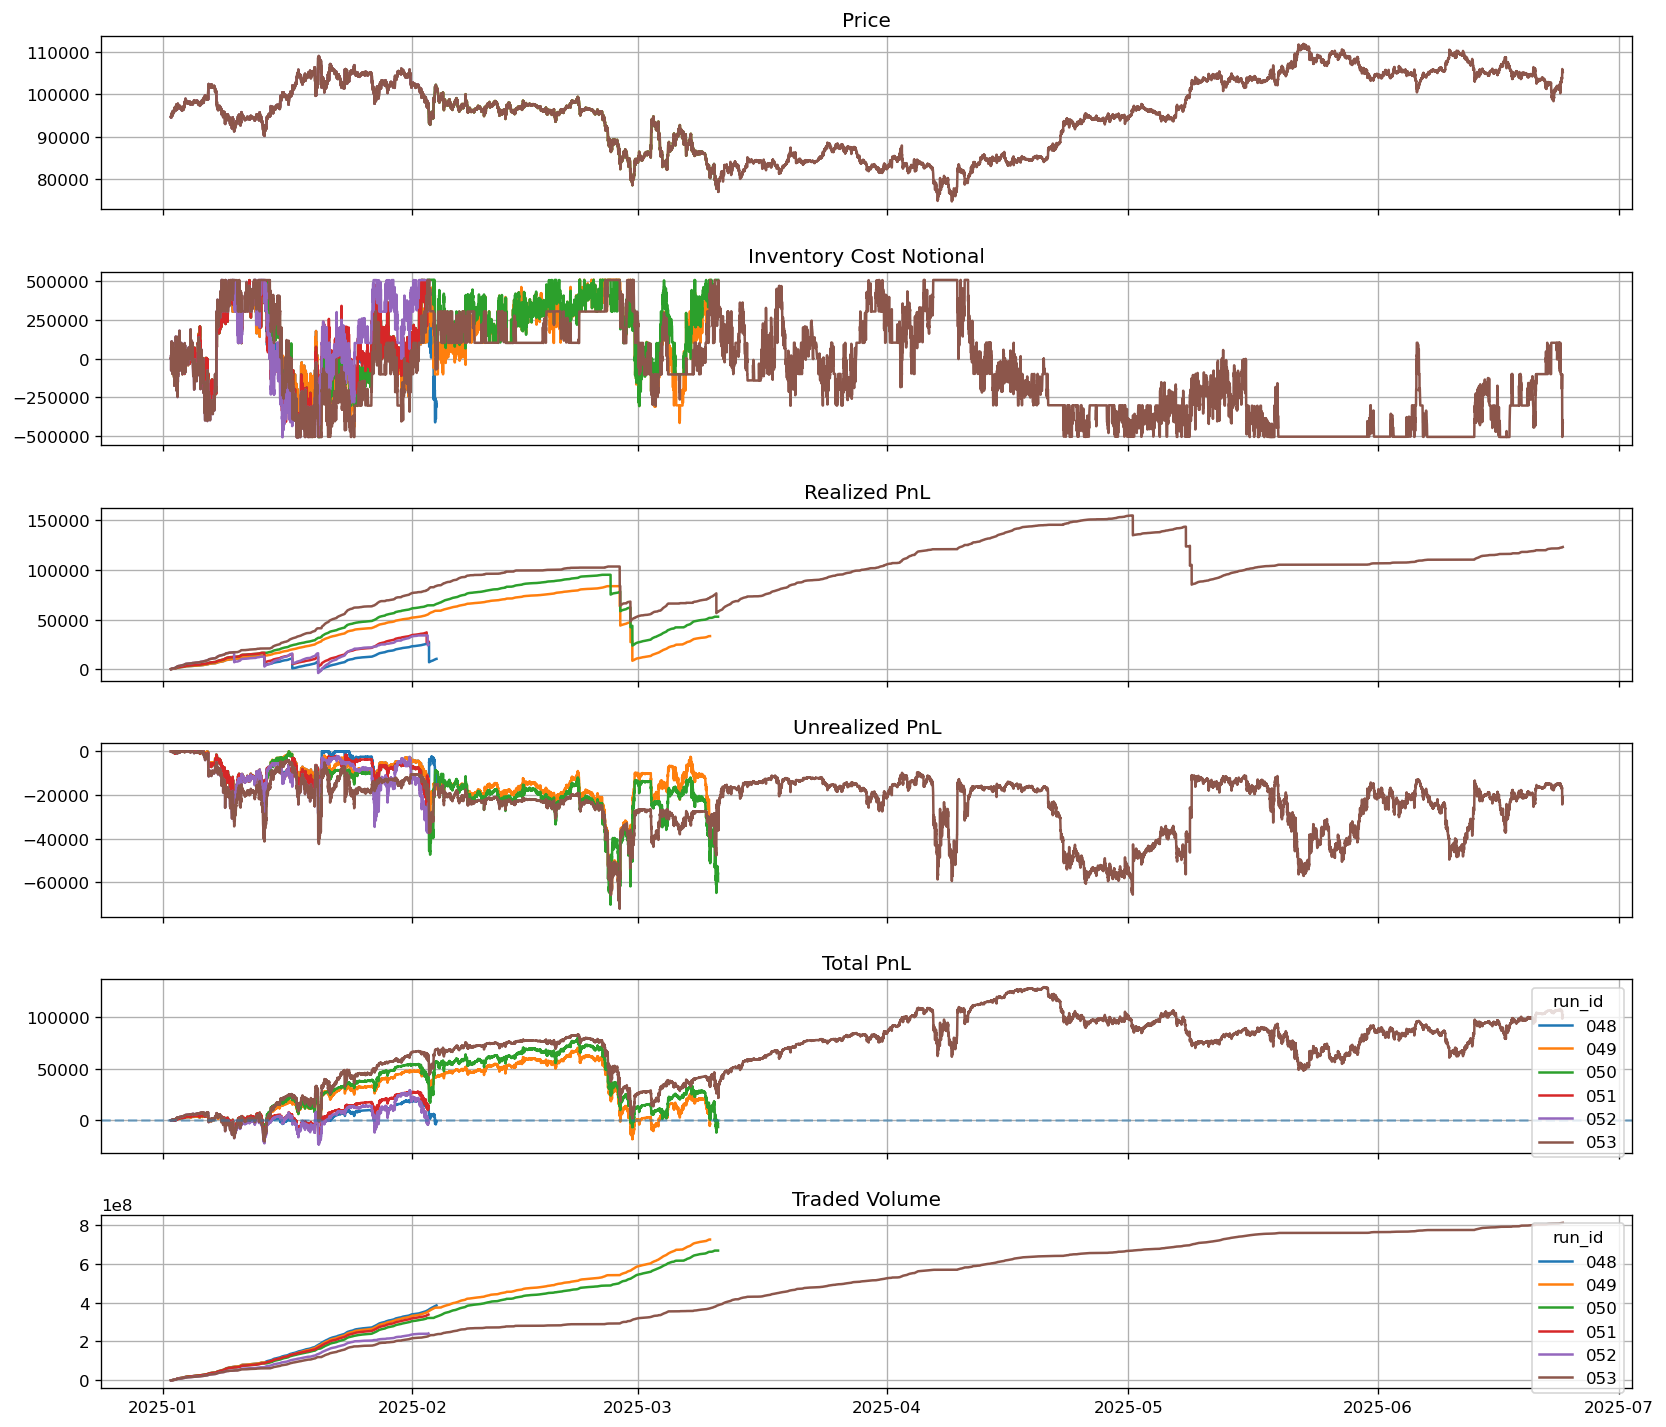

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,048,33,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-840.540881,-0.016768,-1.486450,19599.929208,-29134.314157,-1.486450,-0.016768,1.167958e+07,-0.000002
1,049,67,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-3337.261412,-0.011162,-0.368995,75701.154012,-27933.349195,-0.368995,-0.011162,1.078947e+07,-0.000005
2,050,68,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-6588.858865,-0.018053,-0.561144,82883.809293,-46509.736172,-0.561144,-0.018053,9.786389e+06,-0.000010
3,051,32,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,14006.867543,0.073221,10.625863,13361.457924,141977.026298,10.625863,0.073221,1.055605e+07,0.000041
4,052,32,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-261.607732,-0.014728,-1.477794,25425.607544,-37573.811903,-1.477794,-0.014728,7.478890e+06,-0.000001
5,053,173,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,101893.092766,0.074689,2.669945,78656.948869,210009.752981,2.669945,0.074689,4.648627e+06,0.000126


batch 10: run_id 054..059


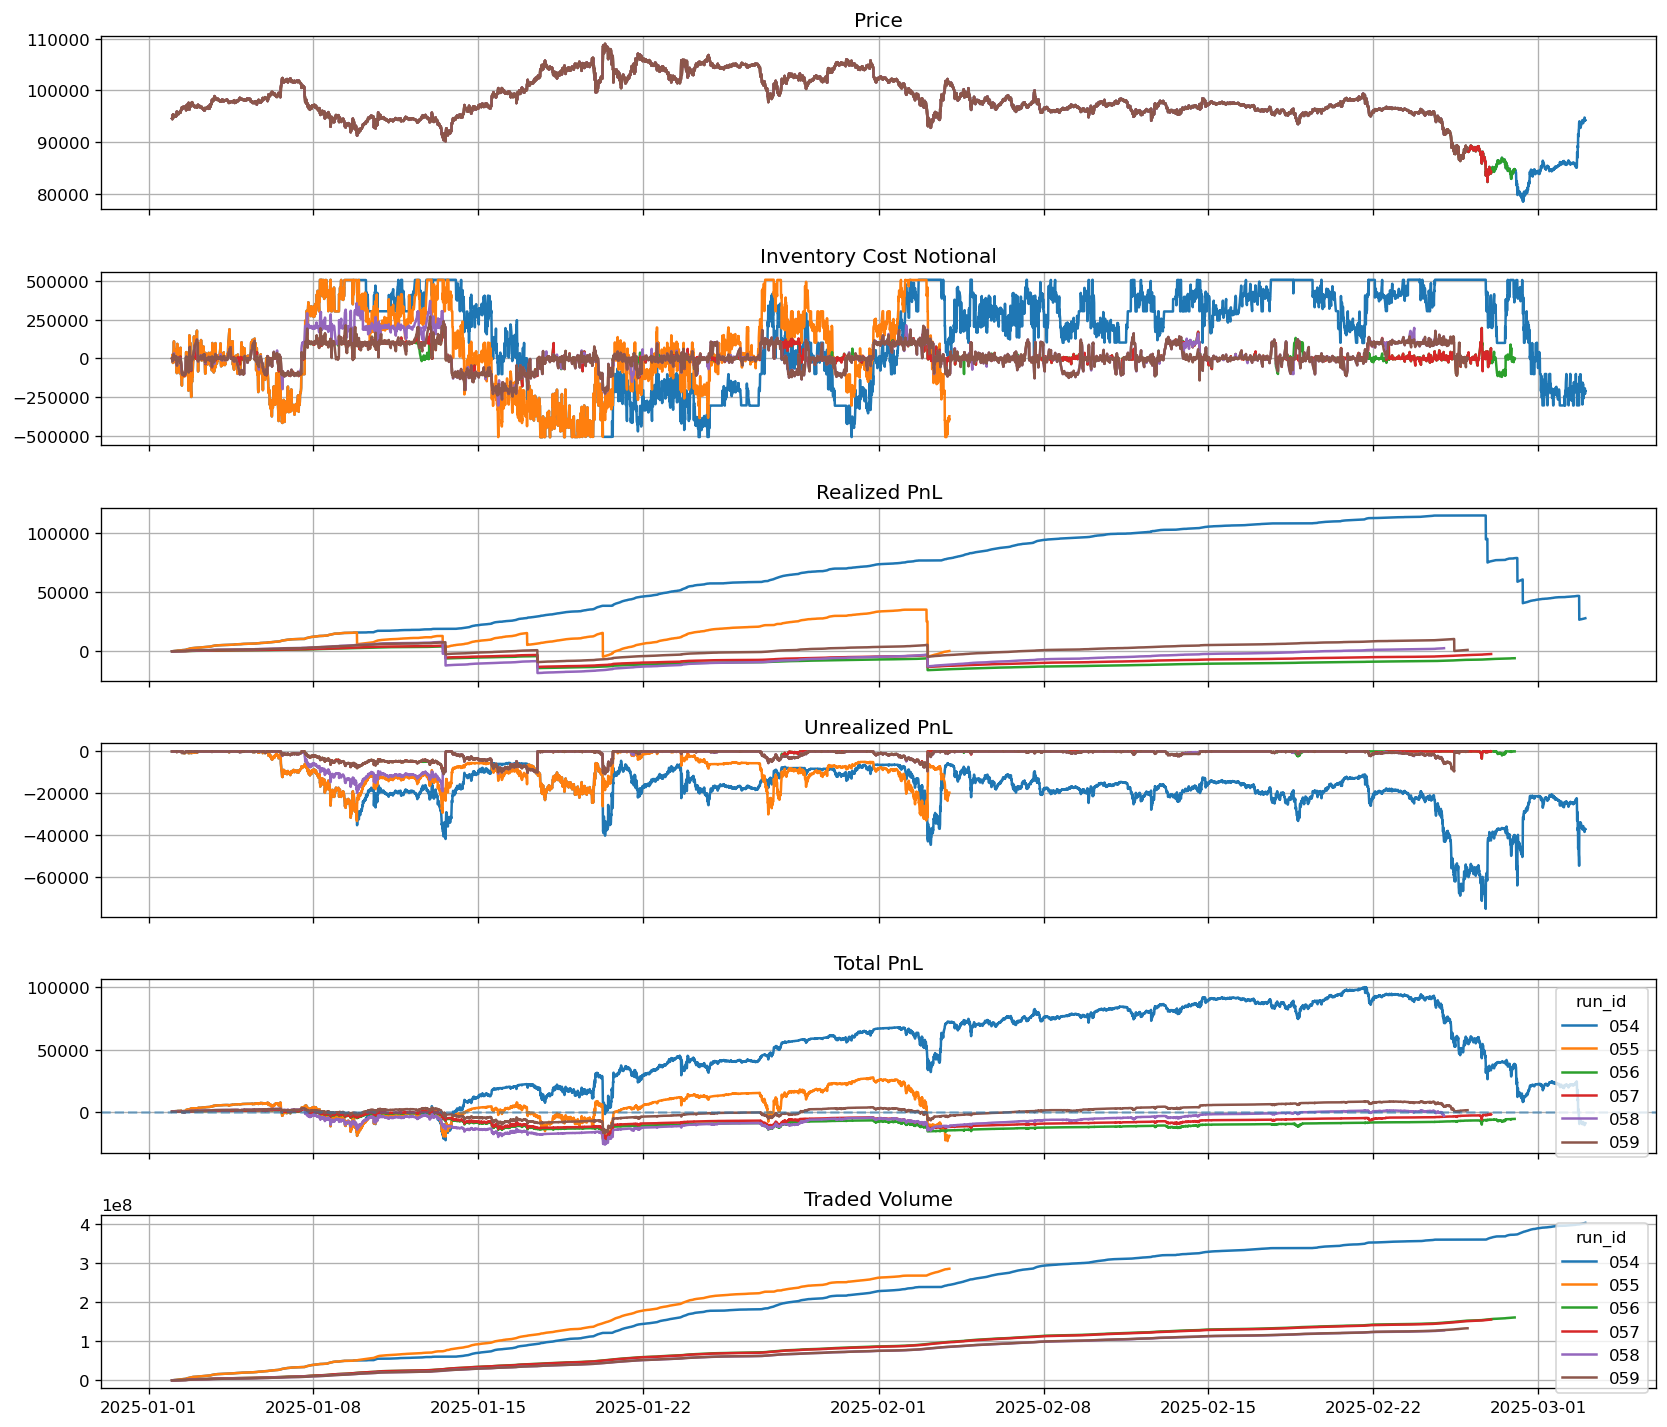

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,054,60,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-9191.463274,-0.023939,-0.688634,106958.728538,-73655.395155,-0.688634,-0.023939,6.658724e+06,-0.000023
1,055,33,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-19395.889114,-0.089241,-5.636913,44740.154436,-252196.367056,-5.636913,-0.089241,8.617222e+06,-0.000068
2,056,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-5790.173808,-0.070134,-2.551335,15896.164409,-40556.441620,-2.551335,-0.070134,2.819259e+06,-0.000036
3,057,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-2247.108879,-0.031227,-1.236396,14721.692904,-18201.842014,-1.236396,-0.031227,2.774955e+06,-0.000014
4,058,54,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-3225.541252,-0.032413,-1.276771,21420.112412,-27348.586294,-1.276771,-0.032413,2.365172e+06,-0.000025
5,059,55,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,1213.907509,0.005360,0.282783,12285.213773,3474.045841,0.282783,0.005360,2.421214e+06,0.000009


batch 11: run_id 060..065


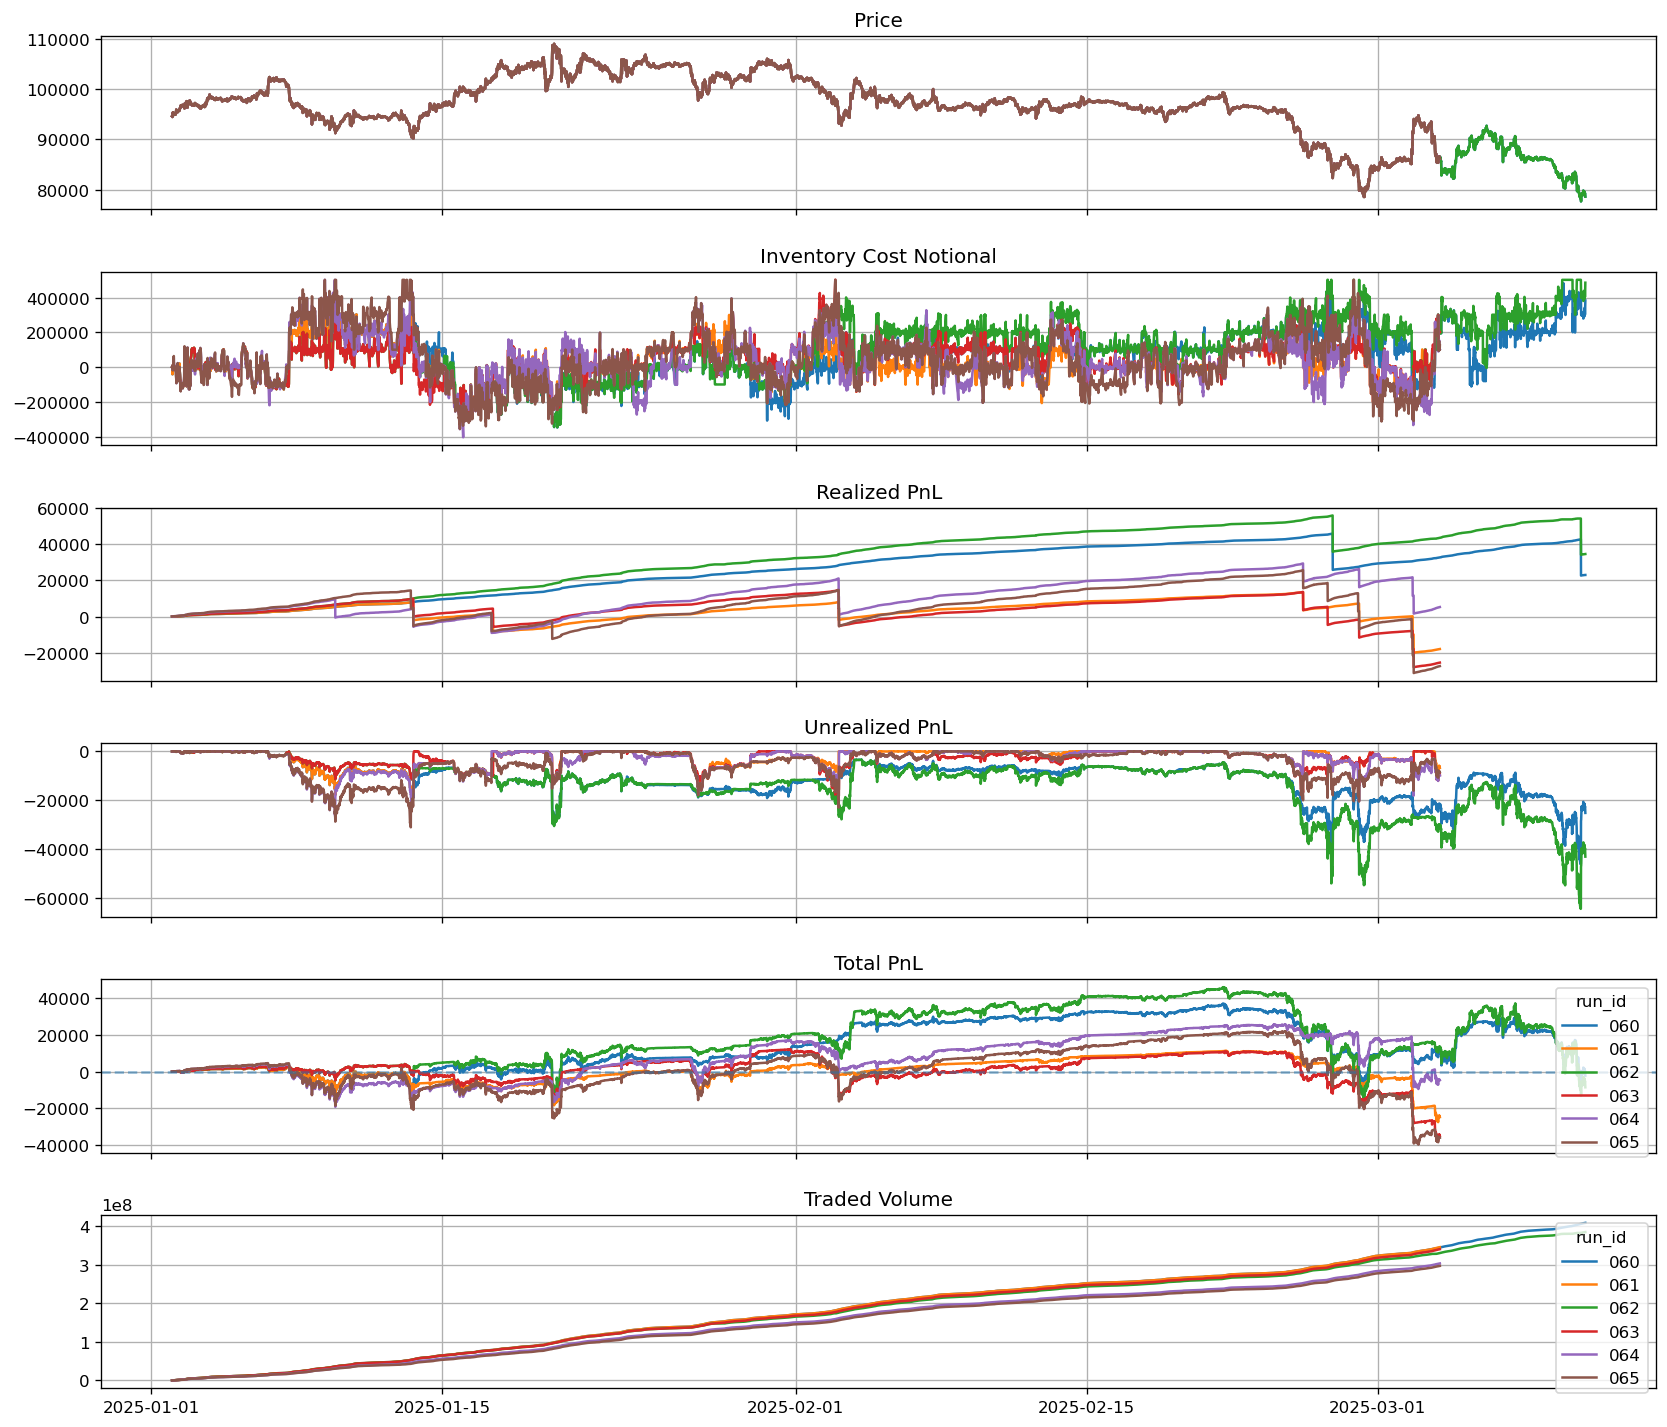

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,060,68,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-2201.311483,-0.009942,-0.408476,37888.268609,-15476.466031,-0.408476,-0.009942,6.028193e+06,-0.000005
1,061,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-24710.365849,-0.138497,-4.323020,35672.316750,-154212.134461,-4.323020,-0.138497,5.681478e+06,-0.000071
2,062,68,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-8521.345176,-0.025302,-0.957280,53157.481468,-50886.619698,-0.957280,-0.025302,5.672712e+06,-0.000022
3,063,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-34971.038324,-0.170040,-4.678235,46540.133787,-217725.691978,-4.678235,-0.170040,5.594280e+06,-0.000103
4,064,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-4660.452241,-0.022567,-1.108481,33598.882705,-37243.723042,-1.108481,-0.022567,4.987191e+06,-0.000015
5,065,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-35893.930000,-0.124317,-3.794704,60086.247270,-228009.540631,-3.794704,-0.124317,4.880195e+06,-0.000121


batch 12: run_id 066..071


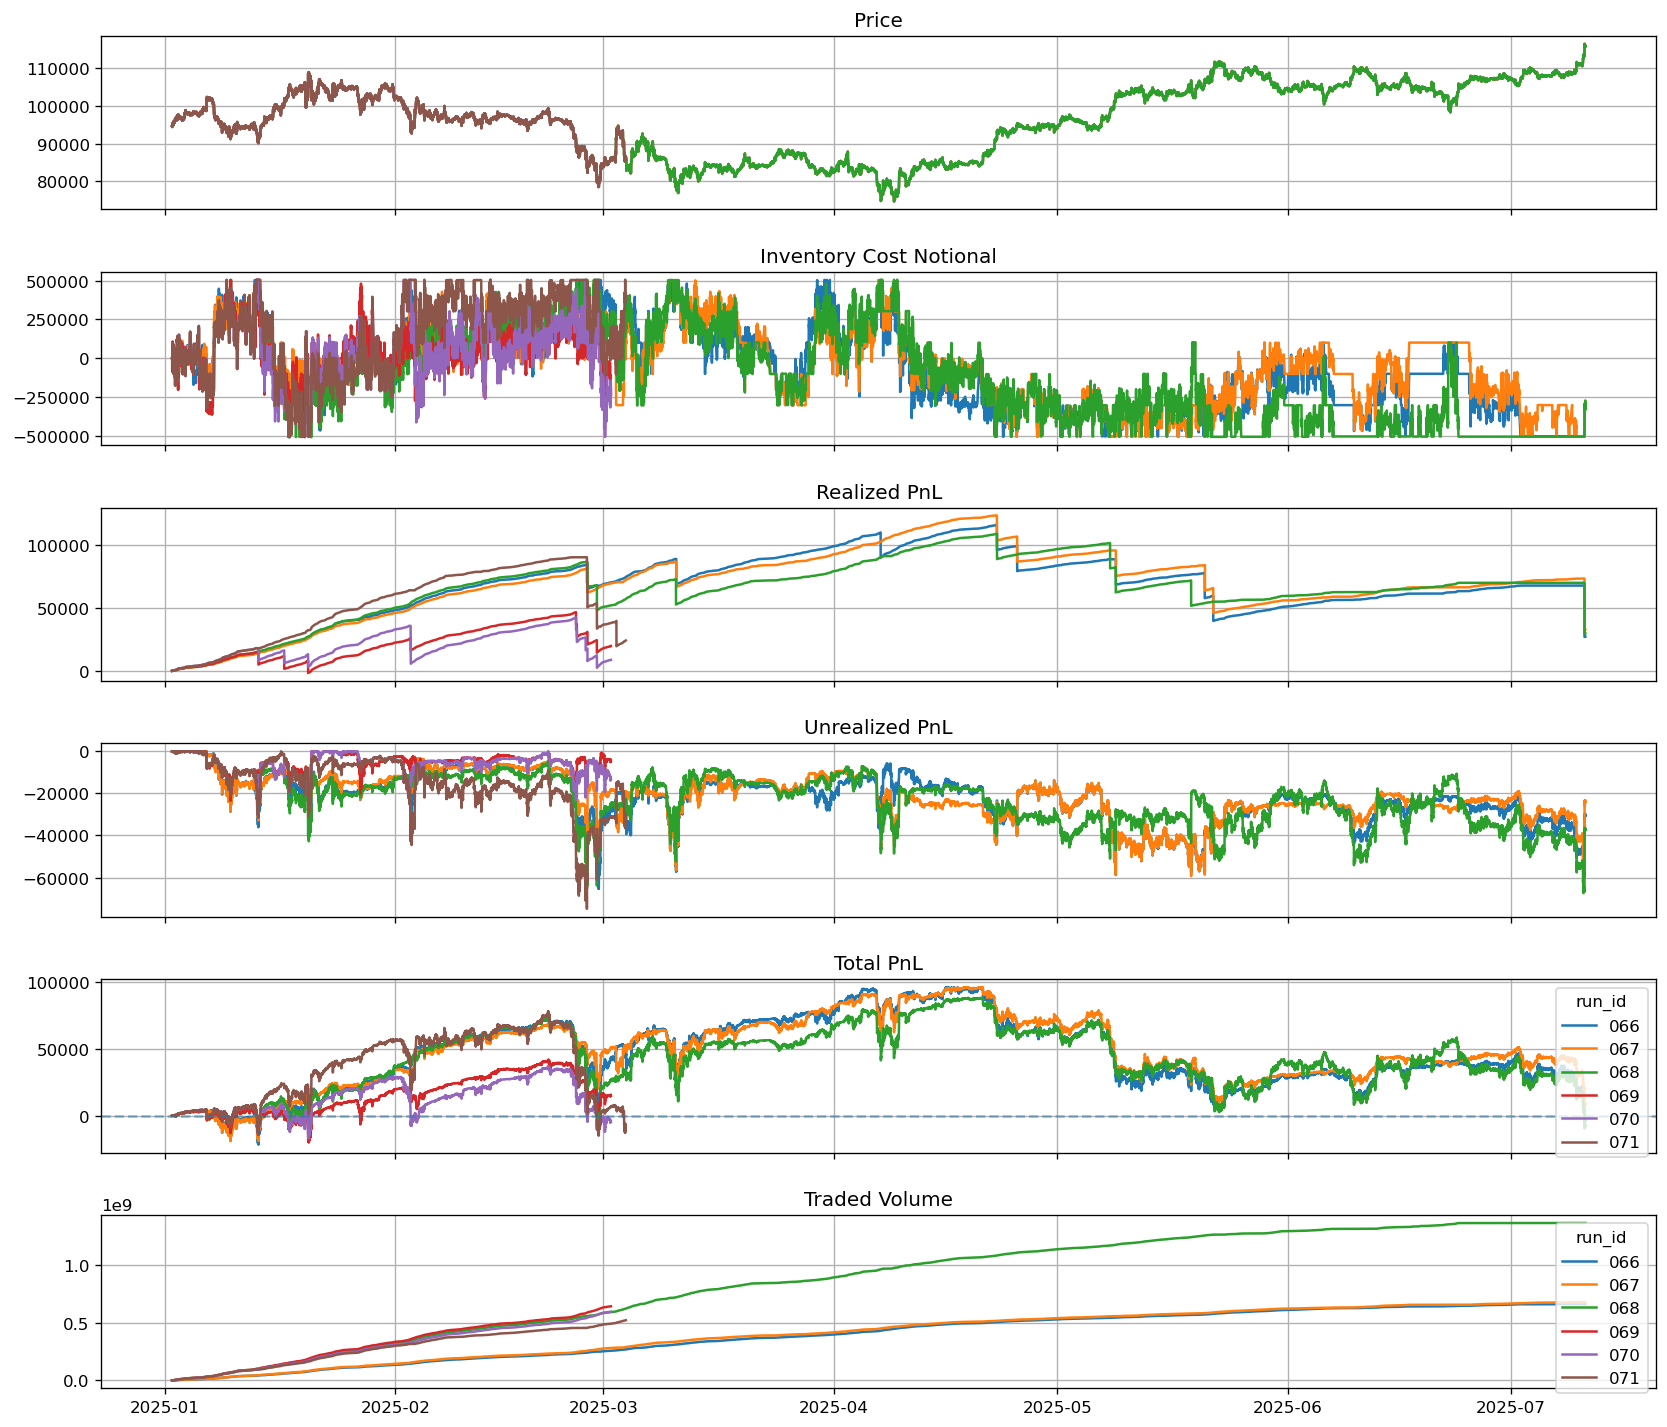

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,066,190,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-3542.504121,-0.004183,-0.099920,99143.133320,-9906.359747,-0.099920,-0.004183,3.468312e+06,-0.000005
1,067,190,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,8524.938265,0.005902,0.155710,87601.451056,13640.445250,0.155710,0.005902,3.564256e+06,0.000013
2,068,190,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-7628.163739,-0.006761,-0.186183,95803.998631,-17837.061455,-0.186183,-0.006761,7.160907e+06,-0.000006
3,069,59,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,14956.580871,0.057633,3.293277,25507.700214,84003.916686,3.293277,0.057633,1.087967e+07,0.000023
4,070,59,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-4443.334267,-0.020276,-0.966566,39829.463550,-38497.823707,-0.966566,-0.020276,1.007948e+07,-0.000007
5,071,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-7948.978661,-0.023439,-0.709291,82533.902118,-58540.566309,-0.709291,-0.023439,8.523794e+06,-0.000015


batch 13: run_id 072..077


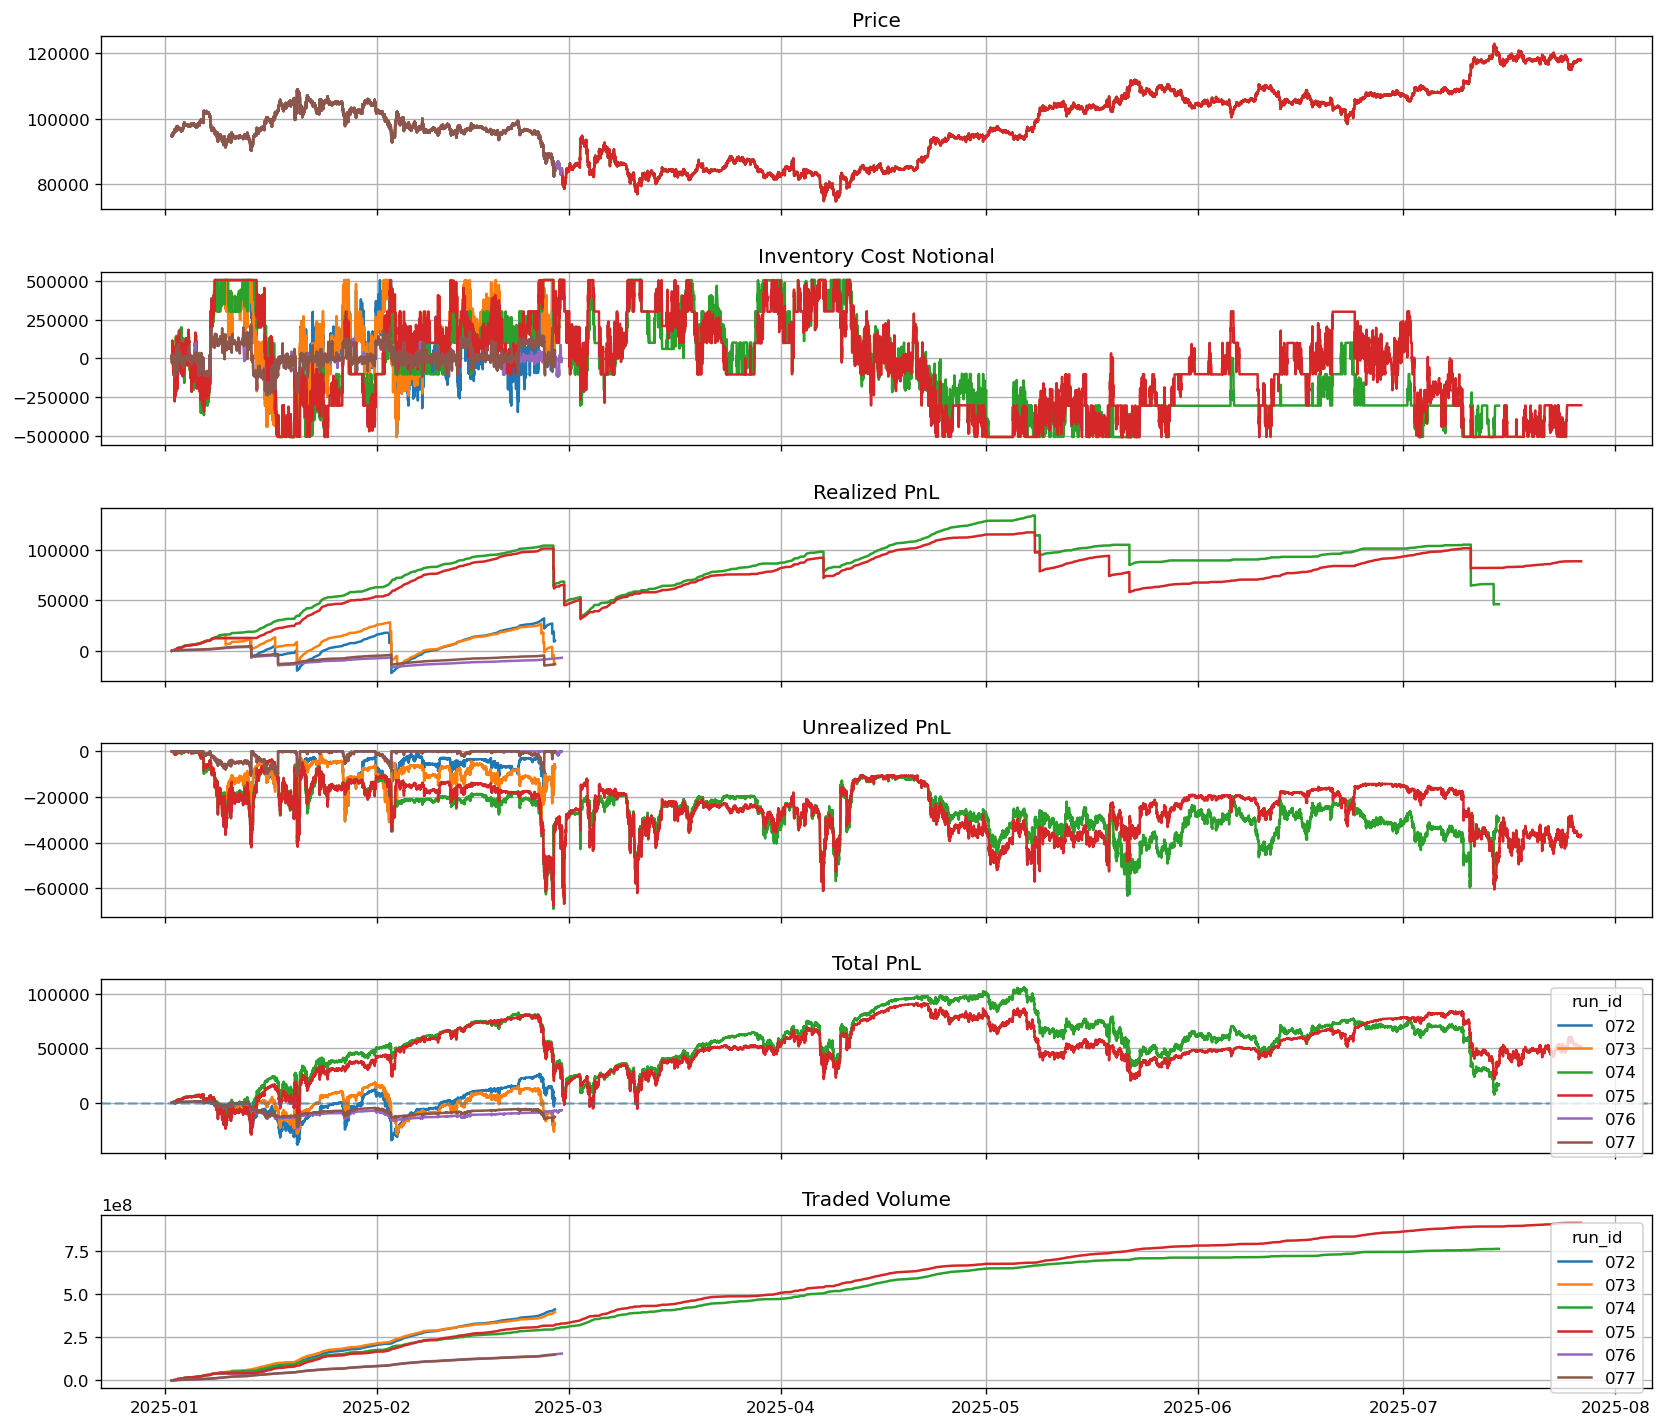

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,072,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,3081.910411,0.001576,0.099418,37626.543519,3740.769333,0.099418,0.001576,7.303487e+06,0.000008
1,073,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-19761.430759,-0.058607,-3.534863,42194.002276,-149150.011922,-3.534863,-0.058607,7.007068e+06,-0.000050
2,074,194,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,16677.735954,0.009487,0.310602,85026.997919,26409.560595,0.310602,0.009487,3.892052e+06,0.000022
3,075,205,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,51871.955962,0.034069,1.154965,76083.437967,87873.702144,1.154965,0.034069,4.394911e+06,0.000057
4,076,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-6898.172956,-0.082370,-2.878089,16568.495692,-47685.598609,-2.878089,-0.082370,2.719148e+06,-0.000044
5,077,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-13236.719950,-0.143051,-6.015218,15136.079620,-91046.823137,-6.015218,-0.143051,2.668529e+06,-0.000088


batch 14: run_id 078..079


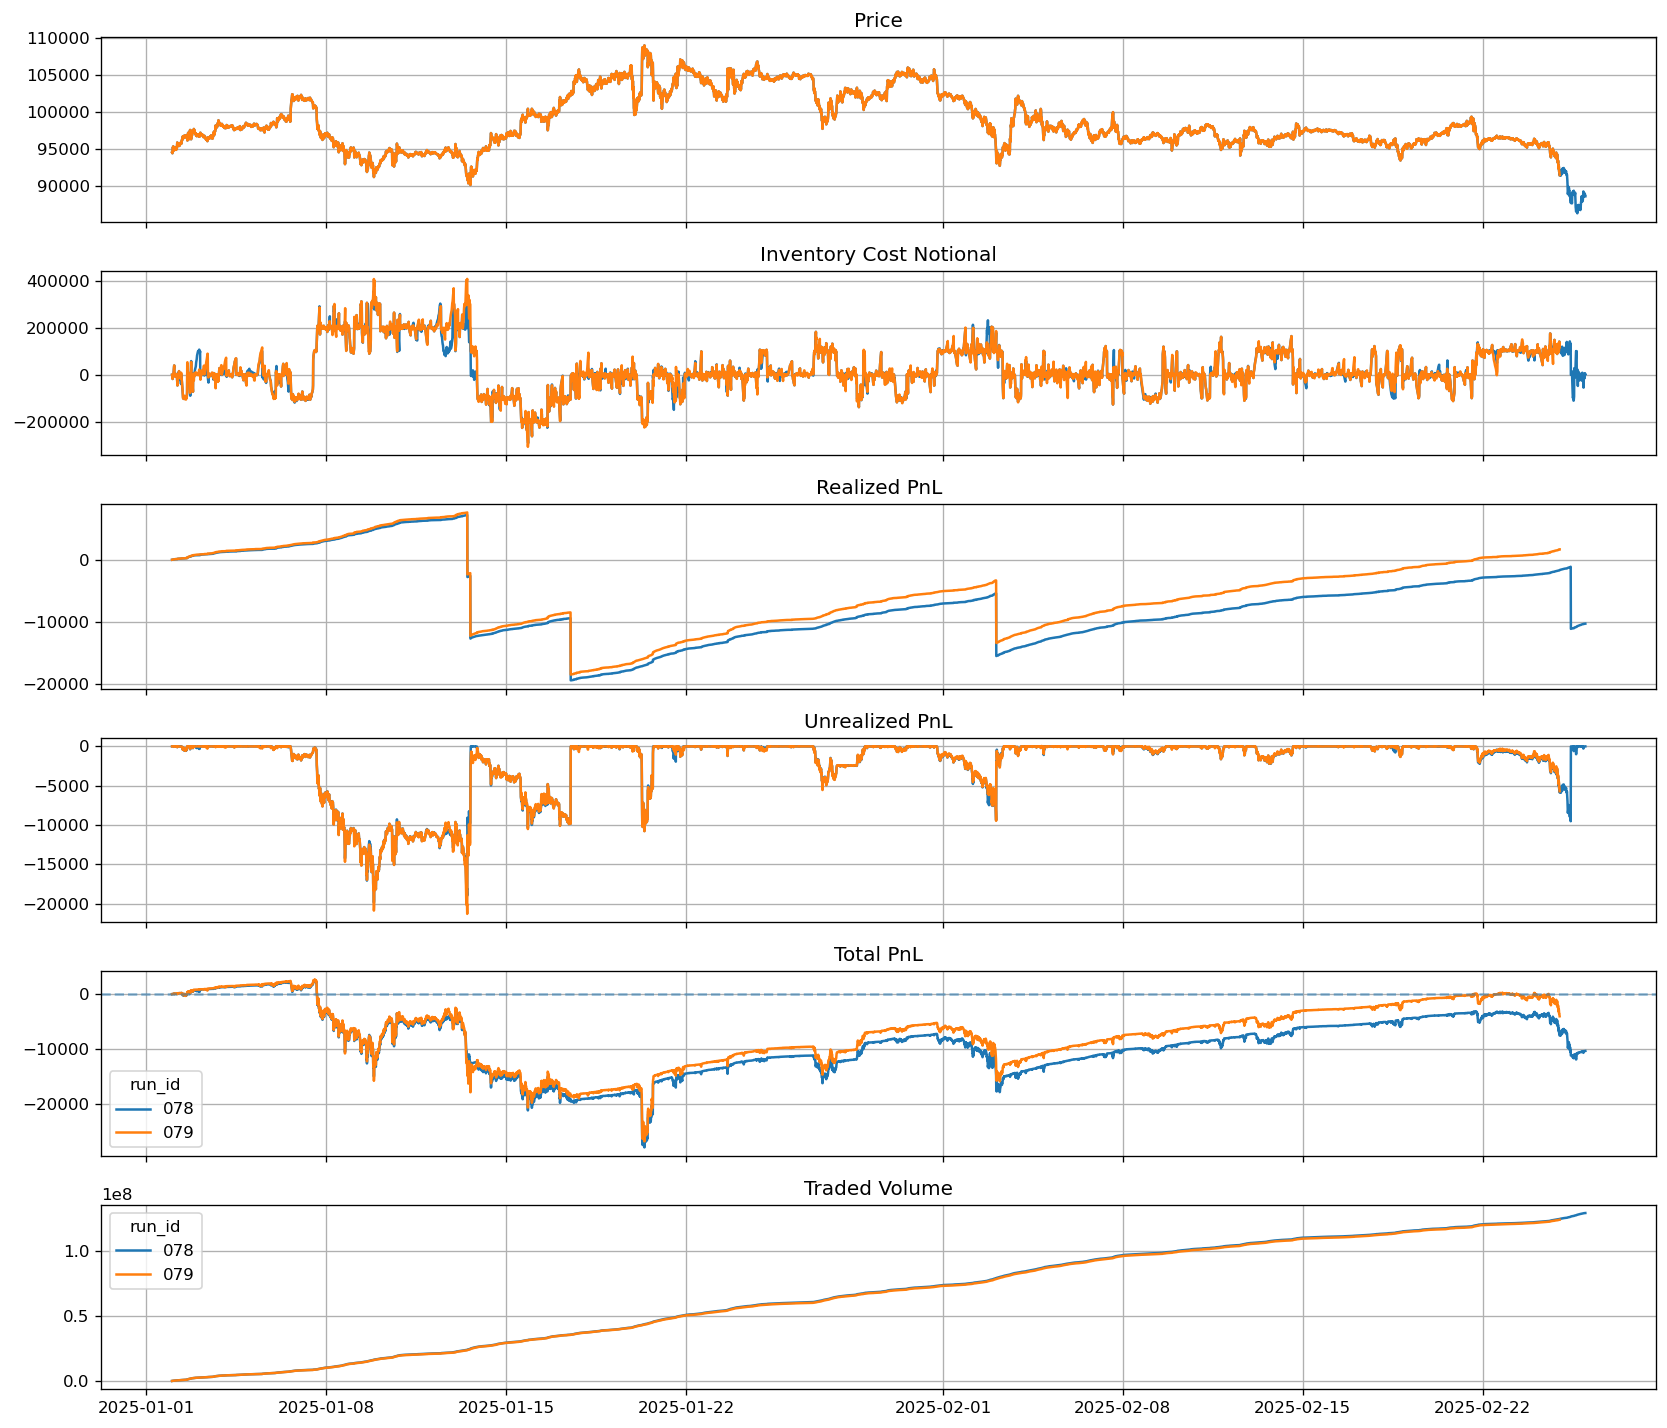

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,078,55,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-10317.999637,-0.086699,-3.333183,22323.545355,-74408.457715,-3.333183,-0.086699,2.342668e+06,-0.000080
1,079,54,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-4024.753517,-0.039667,-1.548165,21585.972679,-33418.645876,-1.548165,-0.039667,2.289109e+06,-0.000033


,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,053,173,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,101893.092766,0.074689,2.669945,78656.948869,210009.752981,2.669945,0.074689,4.648627e+06,1.259588e-04
1,002,205,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,66365.517112,0.043406,1.439616,80521.250349,115919.670519,1.439616,0.043406,6.437659e+06,5.014544e-05
2,075,205,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,51871.955962,0.034069,1.154965,76083.437967,87873.702144,1.154965,0.034069,4.394911e+06,5.700296e-05
3,010,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,47403.081775,0.096083,6.973369,43897.580909,306114.042168,6.973369,0.096083,1.438565e+07,5.745183e-05
4,045,186,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,45253.011080,0.041039,0.891608,96868.103697,86368.423042,0.891608,0.041039,3.709284e+06,6.548708e-05
5,043,174,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,39888.464516,0.041850,1.267420,65044.625749,82438.890872,1.267420,0.041850,5.022950e+06,4.560653e-05
6,046,50,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,37523.147726,0.274232,22.842873,11798.464755,269510.827944,22.842873,0.274232,4.919822e+06,1.526324e-04
7,013,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,34301.163620,0.075867,4.771512,48023.260982,229143.587439,4.771512,0.075867,1.001223e+07,6.068932e-05
8,023,190,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,30684.086687,0.021499,0.860461,65461.728536,56327.284093,0.860461,0.021499,6.107518e+06,2.636245e-05
9,007,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,30214.505126,0.083791,5.370374,33459.428693,179689.650785,5.370374,0.083791,7.681547e+06,6.884708e-05


In [5]:
plot_df = choose_folders(limit=MAX_FOLDERS)
all_metrics = []

for start in range(0, len(plot_df), BATCH_SIZE):
    batch = plot_df.iloc[start : start + BATCH_SIZE]
    first_id = int(batch["run_id"].iloc[0])
    last_id = int(batch["run_id"].iloc[-1])
    print(f"batch {start // BATCH_SIZE + 1}: run_id {first_id:03d}..{last_id:03d}")
    all_metrics.append(plot_folder_batch(batch))

summary_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
display(summary_df.sort_values("pnls", ascending=False).reset_index(drop=True))

Inspect one folder with the full report panels.

run_id=042
/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu0x1x0__opo1__oa1000__pp1__pg2x52x10xexponentialx0__h823df332ca/strat__all


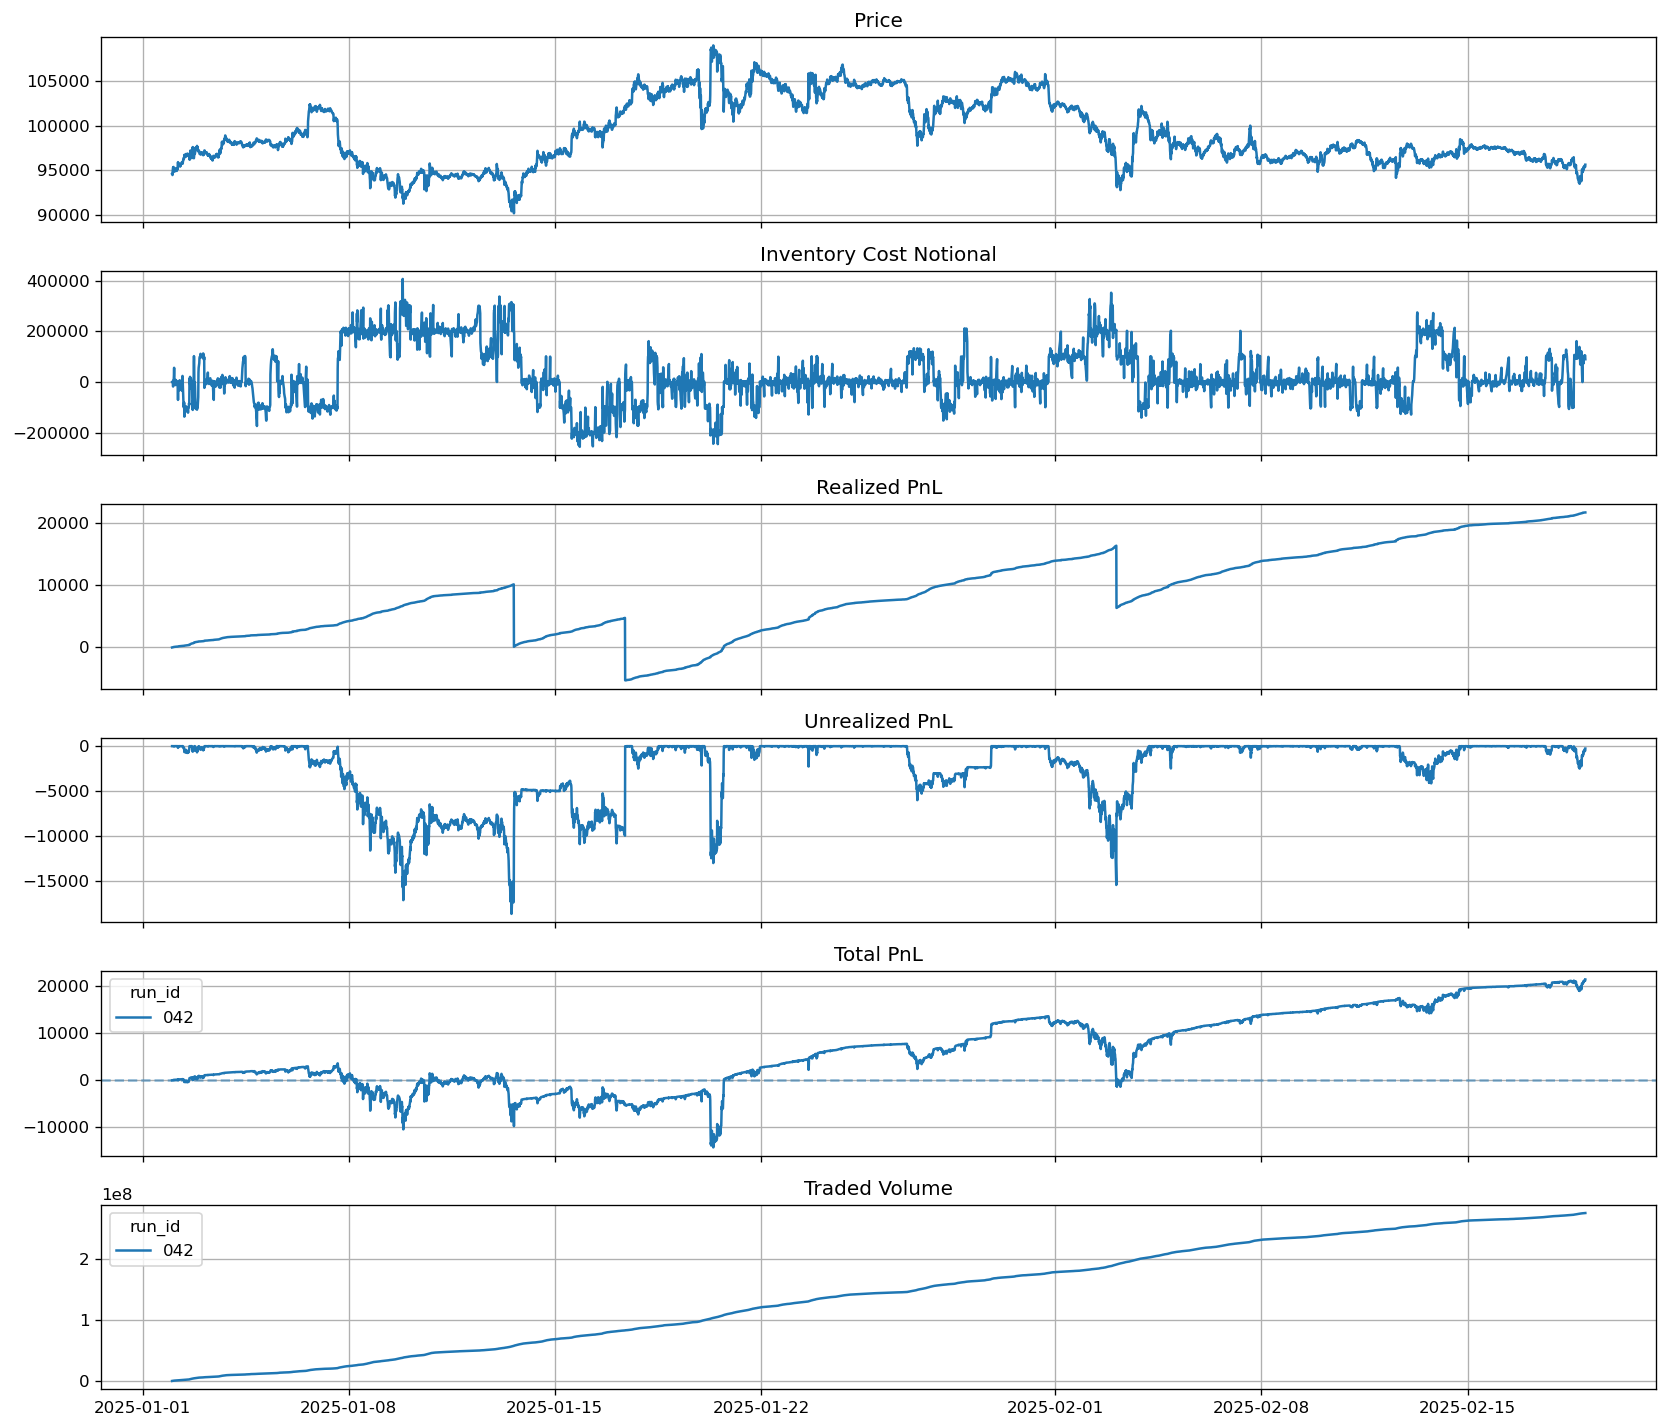

{'pnls': array([21381.42556463]),
 'sharpes': array([0.19901265]),
 'calmars': array([16.35831549]),
 'max_drawdown': array([9763.8661071]),
 'annual_return': array([159720.40220905]),
 'calmar': array([16.35831549]),
 'sharpe': array([0.19901265]),
 'daily_turnover': array([5720642.37444687]),
 'spnl': array([7.78861572e-05])}

In [6]:
FOLDER_ID = int(folder_df["run_id"].iloc[42])
one = folder_df.loc[folder_df["run_id"] == FOLDER_ID].iloc[0]

print(f"run_id={FOLDER_ID:03d}")
print(one["folder"])

report_tools.report(
    one["folder"],
    every=EVERY,
    pnl_only=False,
    srt=SRT,
    end=END,
    exclude_date=EXCLUDE_DATE,
    labels=[f"{FOLDER_ID:03d}"],
    normalize=NORMALIZE,
)

Compare selected folders on one PnL chart.

,run_id,run_name,file_count,folder
0,20,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md1__irbbo_imbalance__ink__vnsigma__ocu...,67,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...


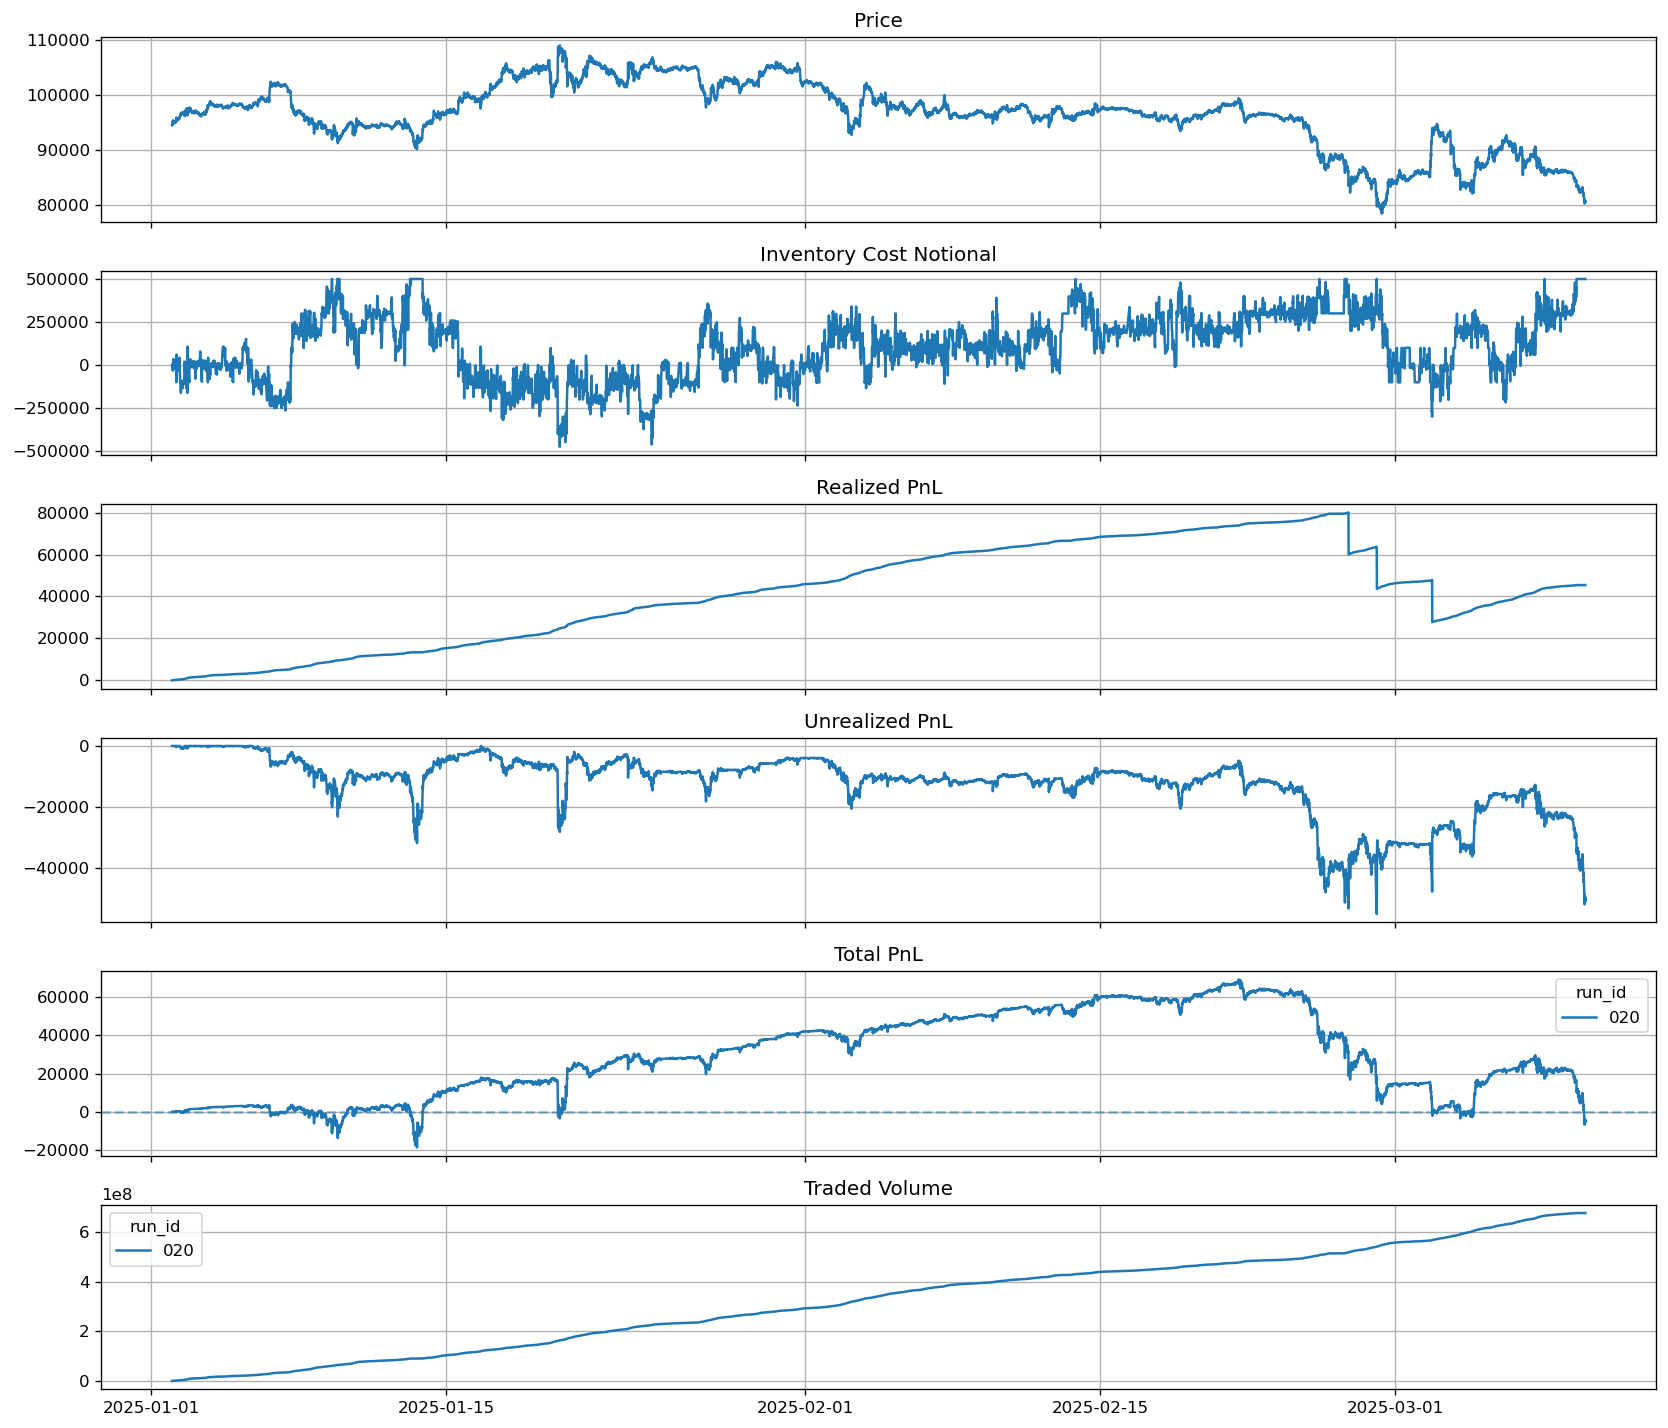

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,020,67,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-4561.084342,-0.015074,-0.469705,71049.092427,-33372.135815,-0.469705,-0.015074,1.013158e+07,-0.000007


,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,020,67,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-4561.084342,-0.015074,-0.469705,71049.092427,-33372.135815,-0.469705,-0.015074,1.013158e+07,-0.000007


In [7]:
SELECTED_IDS = [20]
selected = choose_folders(indices=SELECTED_IDS)
display(selected)

plot_folder_batch(selected, pnl_only=False)

In [8]:
summary_df.sort_values("pnls", ascending=False).iloc[0].folder

'/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu0x1x0__opo1__oa2000__pp1__pg5x105x10xexponentialx__h57a21ab50a/strat__all'

In [9]:
summary_df.sort_values("sharpes", ascending=False)

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
46,046,50,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,37523.147726,0.274232,22.842873,11798.464755,269510.827944,22.842873,0.274232,4.919822e+06,1.526324e-04
41,041,48,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,22564.468010,0.245827,19.843497,8498.604982,168642.038236,19.843497,0.245827,5.801743e+06,8.101396e-05
42,042,48,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,21381.425565,0.199013,16.358315,9763.866107,159720.402209,16.358315,0.199013,5.720642e+06,7.788616e-05
47,047,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,21212.651053,0.113569,7.864459,16653.579863,130971.397331,7.864459,0.113569,4.860979e+06,7.794231e-05
10,010,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,47403.081775,0.096083,6.973369,43897.580909,306114.042168,6.973369,0.096083,1.438565e+07,5.745183e-05
3,003,59,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,26948.818928,0.095670,7.326356,21793.113347,159664.102564,7.326356,0.095670,1.037322e+07,4.404661e-05
7,007,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,30214.505126,0.083791,5.370374,33459.428693,179689.650785,5.370374,0.083791,7.681547e+06,6.884708e-05
27,027,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,28932.868917,0.077905,4.826267,35690.100634,172249.961808,4.826267,0.077905,7.271778e+06,6.963024e-05
13,013,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,34301.163620,0.075867,4.771512,48023.260982,229143.587439,4.771512,0.075867,1.001223e+07,6.068932e-05
53,053,173,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,101893.092766,0.074689,2.669945,78656.948869,210009.752981,2.669945,0.074689,4.648627e+06,1.259588e-04


In [10]:
folders[20]

'/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md1__irbbo_imbalance__ink__vnsigma__ocu0x1x0__opo1__oa1000__pp1__pg2x22x5xexponentialx1__q__h2741f6e6ce/strat__all'